In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from dolfyn.adv import clean as dclean   # dolfyn 1.3.0, dolf_env kernel

# ADV QC
Steps, in the order they are applied:
1. clock drift correction (whole raw record, before anything else)
2. trim to in-water start/end, atmospheric pressure correction, configured salinity (sound speed)
3. beam quality masks (correlation, amplitude)
4. despiking
5. rotation to earth / shore-normal (KVH heading + declination)
6. Z-test: pressure vs velocity consistency (linear wave theory)

Guidelines for QC taken from Holden's PUV QC workflow 
(`/Users/isidorarojas/Desktop/DIRECTORY/2026/NEVAEWA/Nortek_Vector_PUV_Pipeline`).

### 0. Sensor selection and parameters
VC1 is the test sensor. Every section reads `sensor_id` from the cell below, so a single run only
needs that one line changed. Once the pipeline is verified on VC1, list the other sensors in
`SENSORS` and use the batch cell at the end of the notebook ("Run the other sensors"), which
executes this notebook once per sensor and keeps an executed copy of each for review.

In [2]:
##-----sensor selection-----##
sensor_id = "VC1"
# Sensors for the batch cell at the end of the notebook. Only VC1 until the pipeline is verified.
# All processed Vectors: ["VA1", "VB1", "VC1", "VC2", "VD1", "VD2", "VE1", "VE2", "VE3"]
# (VE1's clock drift is footnoted in sensor_notes.csv, so section 1 stops on it until that is resolved.)
SENSORS = ["VA1", "VB1", "VC1", "VC2", "VD1", "VD2", "VE1", "VE2", "VE3"]

##-----parameters-----##
# Everything tunable lives here.
# section 2: trim + pressure + sound speed
P_WET        = 3.0    # dbar. Below this the instrument is out of the water. In air it reads
                      # ~0.8-1.0 dbar and the shallowest Vector sits at ~4 m, so 3 dbar
                      # separates the two cleanly.
BUFFER_S     = 10     # s taken off each end of the window, AFTER the handling edges
HEAD_STD_MAX = 0.25   # deg. Floor of the handling threshold on the 1-min circular heading std
HEAD_STD_K   = 3.0    # threshold = max(HEAD_STD_MAX, HEAD_STD_K * median 1-min std of this sensor).
                      # Compass noise differs by sensor (median VC2 0.09 deg, VC1 0.23 deg), while
                      # handling gives > ~0.7 deg. The median, not the std, sets the scale: the
                      # handling minutes themselves inflate the std 20-30x (VC1: std 0.46, MAD 0.02).
CALM_MIN_MIN = 30     # min. A calm stretch must last this long to count as "deployed"
P_AIR        = 1.5    # dbar. Below this the instrument is in air, used for the in-air offset.
                      # Excludes readings taken while the frame hung below the boat (~2.6 dbar on VC2).
S_TRUE       = 35.0   # PSU, ASSUMED ambient salinity; the instrument was configured with 33.5.
                      # Replace with a measured value (CTD/RBR) if one exists.
RHO, GRAV    = 1023.0, 9.79   # kg/m3, m/s2 (21 N): dbar -> m of water, 1 dbar = 1e4 Pa

# section 3: beam quality
CORR_MIN         = 70     # %. Minimum beam correlation (Nortek recommendation, lab corrMin)
AMP_DB_PER_COUNT = 0.43   # dB per amplitude count (Nortek), for SNR = 0.43 * (amp - noise floor)
SNR_MIN          = 5.0    # dB. Low-SNR flag, diagnostic only unless APPLY_SNR
APPLY_SNR        = False  # True also NaNs velocity where any beam is below SNR_MIN

# section 4: despiking
DESPIKE_METHOD   = "universal"  # "universal": threshold on the wave-free residual, tunable with DESPIKE_K
                              # (chosen). "GN2002": dolfyn.adv.clean.GN2002 on the same residual; on VC1 it
                              # removed 1.09 % vs 0.24 % and clipped crests (u skewness -1.4 % in big waves).
GN_NPT           = 7200   # GN2002 block length (samples), 1 h at 2 Hz
DESPIKE_K        = 1.5    # multiplier on the universal threshold sqrt(2 ln n) = 4.21 (n = 7200/h),
                          # so 1.5 -> 6.3 robust sigma. A judgment call, no clean break: on VC1 the
                          # share of flags with a correlation dip rises only gradually with severity
                          # (21 % at 4-5 sigma, 44 % above 12; background 15 %), and ~45 % of u-triggered
                          # flags sit on wave crests at EVERY severity. K = 1.5 does not fix that share;
                          # it cuts the number of flags ~4x (0.87 -> 0.23 % of samples) and u-crest
                          # removals ~6x. See the severity table and u-skewness check in section 4.
DESPIKE_MAX_ITER = 2      # detection passes. More passes cascade up the steep fronts of breaking
                          # waves (each replacement makes the next sample look like a spike).
MAX_FILL         = 4      # samples (2 s). NaN runs up to this long are filled with dolfyn
                          # clean_fill (cubic, 12 points either side); longer gaps stay NaN. Spline error on VC1 u: 5-13 % of the
                          # hourly std for 1-2 samples, 11-17 % for 4, 20-38 % for 6.
SEG_MIN_VALID    = 0.5    # an hour with less valid velocity than this is not despiked
                          # (too few samples for a meaningful threshold)
NAN_MAX_FRAC     = 0.10   # lab nanMaxFrac: 1-h segments with more NaN are dropped before spectra

# section 5: rotation
DECLINATION_DEG  = 9.26   # deg, + = east. WMM-2025 at 21.297 N, 158.042 W on 2026-08-15 (NOAA NCEI
                          # calculator; uncertainty 0.33 deg; IGRF-14 gives 9.27). It changes -0.04 deg/yr
                          # and < 0.01 deg across the array, so one value covers every sensor and the record.
HEAD_UP          = True   # probe heads point up (field note 2026-09-18). In Nortek XYZ that makes +Z point
                          # DOWN (+Y 90 deg clockwise of +X from above), i.e. roll = 180. Checked on the
                          # data in section 5 (w vs dp/dt).
SHORE_NORMAL_OVERRIDE = None  # deg true, onshore-pointing. None = use this sensor's transect value from
                          # sensor_notes.csv ("Shore Normal Onshore (deg true)" = shoreline heading W->E
                          # minus 90; A 355, B 336, C 350, D 339, E 3). Set a number only to test another
                          # angle. Section 5 prints the wave and mean-current estimates to compare against.

# section 6: Z-test
ZT_SEG_S   = 1024          # s. Record segment; each is linearly detrended before its spectra (lab segDur)
ZT_NFFT    = 256           # samples (128 s). Welch window inside a segment, Hann, 15 windows -> ~30 dof
ZT_OVERLAP = 0.5           # Welch overlap
ZT_F_SS    = (0.04, 0.25)  # Hz, sea-swell band for Z (lab fSS)
ZT_F_IG    = (0.004, 0.04) # Hz, infragravity band (lab fIG). Only ~5 bins at df = 0.0078 Hz, diagnostic
ZT_WINDOW  = (0.5, 2.0)    # acceptable record median Z (Elgar, Raubenheimer & Guza 2005; lab ztest_record_flag)
ZT_MIN_SEG = 20            # fewer valid segments than this = "insufficient", not a failure
Z_P_HAB    = 0.20          # m, pressure port above the bed. ESTIMATE (lab HI26_config doffp, "pending
                           # DeploymentNotes"). Sets the total depth h = mean p + Z_P_HAB.
Z_U_HAB    = None          # m, velocity sampling volume above the bed. None = same as Z_P_HAB (the lab's
                           # co-located assumption). Z moves < 0.3 % for 0-0.7 m on VC1/VE3 (printed below).

# paths: data/processed/qc/ for QC'd files, figs/qc/ for QC figures
data_path = "/Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/data/processed"
root    = Path(data_path).parents[1]              # .../4EWA
qc_dir  = Path(data_path) / "qc"
fig_dir = root / "figs" / "qc"
qc_dir.mkdir(exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

# figure style, same palette as the orientation figures in adv_raw2nc.ipynb
INK, INK2, GRID, SERIES = "#0b0b0b", "#52514e", "#e4e3df", "#2a78d6"
BEAM_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]   # beams 1, 2, 3 (fixed order)
plt.rcParams.update({
    "axes.edgecolor": INK2, "axes.labelcolor": INK2, "xtick.color": INK2,
    "ytick.color": INK2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white", "font.size": 9,
})
sensor_id = "VA1"   # injected by the batch cell

### 1. Clock Drift Correction
 - The standard approach is a linear drift from 0 at start to the measured drift at recovery, as linspace over the record. Check
   the CSV sign convention: negative means the sensor clock is slow, so corrected $ time = t − drift·(fraction elapsed)$ only when that sign is respected.

 - With no measured Vector drift:
   - Tide cross-correlation (NOAA Honolulu 1612340) catches time-zone and
     hour-scale
     offsets. Derive the lag sign as in PIPELINE_NOTES.md ("recovered filename
     clock is
     LOCAL time"). A lag scan alone can't tell ±. It does not resolve seconds.
   - VC2 vs ADCP are co-located (same lat/lon). Wave-band p–p cross-correlation
     gives
     seconds-level sync for VC2 against the ADCP, which has a known drift of −6
     s.
   - Other pairs (Vector vs nearby P-sensor): lag = propagation time + drift,
     so drift
     can only be bounded. Split lags over time: a drift trend across the
     deployment is
     separable from a constant propagation lag.

#### 1a. Load, drop seam fillers, linear drift correction

**Why this is first.** The drift builds up from when the clock was set (≈ the first raw sample,
on deck, before deployment), not from when the frame settled on the bed. Correcting the whole raw
record first means every later step (barometer interpolation, trim edges, tide check) works on
true UTC times.

1. **Drop seam filler records.** At each `.vec` file boundary, and after the recorder was stopped,
   the reader emits placeholder samples with `p = 0`, all beam correlations `= 0`, `temp = NaN`
   and a timestamp that duplicates the next real sample. Left in, they read as "out of water"
   mid-deployment. They are dropped, not interpolated.
2. **Linear drift.** The drift in `sensor_notes.csv` is the instrument clock minus PC internet
   time, measured at download. `+` = sensor clock fast, `-` = slow. The error builds up roughly
   linearly from when the clock was set (≈ first raw sample) to when it was checked (≈ last raw
   sample: logging stopped when the instrument was connected to the Nortek software). So each
   sample is shifted by
   `t_true = t - drift * (t - t_raw_start) / (t_raw_end - t_raw_start)`.
   This works for either sign: a fast clock (`+`) moves timestamps earlier, a slow one later.
   Timestamps are shifted, not resampled, so no data values change.

The tide-gauge check of the corrected clock needs the atmosphere-corrected pressure, so it runs
at the end of section 2 (2b).

In [3]:
##-----load raw + drop seam filler records-----##
# .load() pulls the whole file into memory (~400 MB for 10.7 M samples). Everything below
# indexes it repeatedly, and that is much faster in memory than lazily from disk.
ds_raw = xr.open_dataset(Path(data_path) / f"{sensor_id}.nc").load()
n_raw = ds_raw.sizes["time"]

# Seam fillers: pressure exactly 0, all three beam correlations 0, temp NaN, and a timestamp
# that duplicates the next real sample. They are not measurements, so drop them (no
# interpolation). Both conditions must hold, so a real low-correlation sample is never caught here.
filler = (ds_raw.p.values == 0) & (ds_raw["corr"].values == 0).all(axis=0)   # corr is (beam, time)
ds = ds_raw.isel(time=~filler)

# check the time base afterwards: spacing should be 0.5 s (2 Hz). Any > 0.5 s is a real gap
# where a filler replaced a sample, rather than duplicating one.
dt = np.diff(ds.time.values) / np.timedelta64(1, "s")
print(f"{sensor_id}: dropped {filler.sum()} filler samples "
      f"(p = 0, corr = 0) of {n_raw:,}")
print(f"  sample spacing after drop: min {dt.min():.3f} s, max {dt.max():.3f} s, "
      f"{(dt > 0.51).sum()} gap(s) > 0.5 s")

VA1: dropped 5 filler samples (p = 0, corr = 0) of 10,998,815
  sample spacing after drop: min 0.500 s, max 1.000 s, 2 gap(s) > 0.5 s


In [4]:
ds

<xarray.Dataset> Size: 517MB
Dimensions:              (x: 3, x*: 3, time: 10998810, beam: 3, earth: 3,
                          inst: 3)
Coordinates:
  * x                    (x) int64 24B 1 2 3
  * x*                   (x*) int64 24B 1 2 3
  * time                 (time) datetime64[ns] 88MB 2026-07-18T05:20:03.00000...
  * beam                 (beam) int64 24B 1 2 3
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables:
    beam2inst_orientmat  (x, x*) float32 36B 2.75 -1.412 ... 0.3428 0.3281
    heading              (time) float32 44MB 244.6 244.6 244.7 ... 358.1 nan
    pitch                (time) float32 44MB -165.0 -165.0 -164.9 ... 151.6 nan
    roll                 (time) float32 44MB -156.3 -156.4 -156.4 ... 41.5 nan
    temp                 (time) float32 44MB 23.09 23.1 23.1 ... 25.2 25.2 nan
    orientation_down     (time) bool 11MB True True True True ... True True True
    amp                  (beam, time) uint8 33MB 46 47 46 47 46 ... 46 46 45 46
    corr                 (beam, time) uint8 33MB 3 5 7 10 7 4 7 ... 9 5 2 3 1 4
    p                    (time) float32 44MB 1.052 1.052 1.066 ... 1.575 1.568
    u                    (time) float32 44MB -1.279 6.327 -2.124 ... 1.478 1.489
    v                    (time) float32 44MB 1.063 -0.028 0.21 ... 1.214 -0.642
    w                    (time) float32 44MB -0.613 -0.657 ... 0.196 -0.686
Attributes: (12/63)
    inst_make:                      Nortek
    inst_model:                     Vector
    inst_type:                      ADV
    rotate_vars:                    vel
    n_beams:                        3
    profile_mode:                   continuous
    ...                             ...
    dropped_variables:              orientmat, batt, c_sound, error, status
    complex_vars:                   []
    heading_kvh_magnetic_deg:       343.9
    transect:                       A
    shoreline_heading_deg_true:     85.0
    shore_normal_onshore_deg_true:  355.0

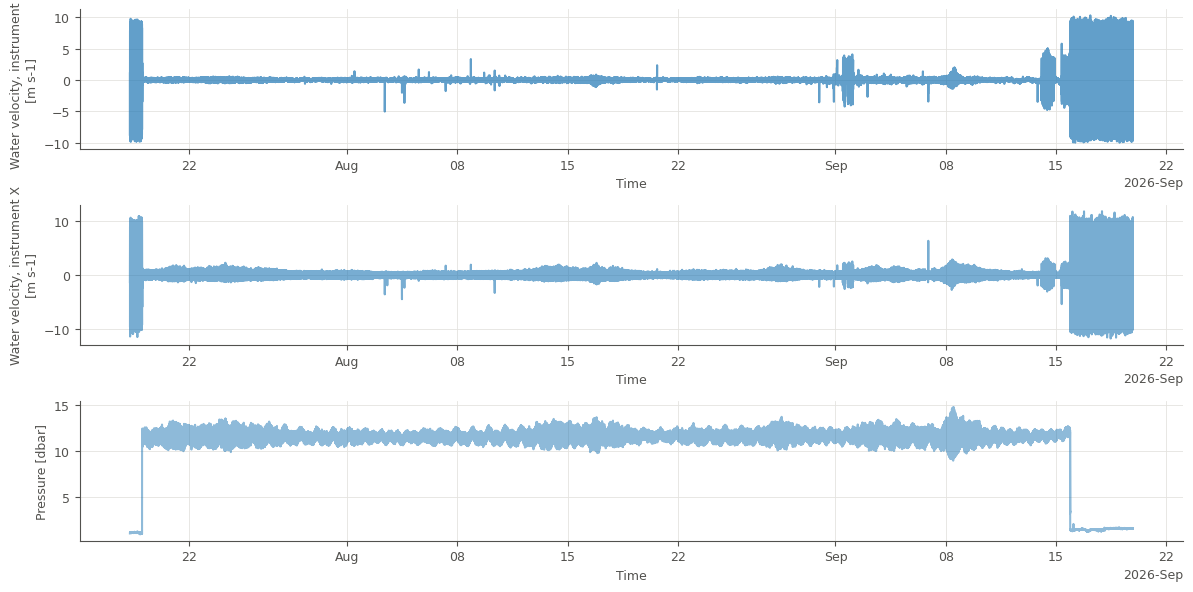

In [5]:
plt.figure(figsize=(12, 6))
plt.subplot(3,1,1)
ds['v'].plot(alpha=0.7)
plt.subplot(3,1,2)
ds['u'].plot(alpha=0.6)
plt.subplot(3,1,3)
ds['p'].plot(alpha=0.5)

plt.tight_layout()

In [6]:
##-----clock drift: linear correction-----##
# drift from the deployment notes. The column holds strings like "+3.571"; a trailing "*" marks a
# footnoted value (e.g. VE1, whose PC was on Hawaii time), so stop and read the footnote.
notes = pd.read_csv(root / "data" / "metadata" / "sensor_notes.csv", dtype=str, skipinitialspace=True)
notes.columns = notes.columns.str.strip()
row = notes[notes["Processed Data Sensor Name (.nc file)"].str.strip() == sensor_id].iloc[0]
drift_str = row["Clock Drift (seconds) over Deployment Duration***"].strip()
assert not drift_str.endswith("*"), f"{sensor_id} drift '{drift_str}' is footnoted; check sensor_notes.csv"
drift = float(drift_str)            # s; + = sensor clock fast, - = slow (CSV convention)

# The drift builds up over the whole time the clock ran, so the fraction elapsed is measured on
# the RAW record span: clock set ~ first sample, drift checked ~ last sample.
t_raw0, t_raw1 = ds_raw.time.values[[0, -1]]
t_old = ds.time.values
frac  = (t_old - t_raw0) / (t_raw1 - t_raw0)          # 0 at clock set -> 1 at drift check
shift = drift * frac                                    # s to subtract from each timestamp
ds = ds.assign_coords(time=t_old - np.round(shift * 1e9).astype("timedelta64[ns]"))

ds.attrs.update({
    "qc_clock_drift_s": drift,
    "qc_clock_drift_convention": "+ = sensor clock fast; t_true = t - drift * frac_elapsed",
    "qc_clock_raw_start": str(t_raw0),
    "qc_clock_raw_end": str(t_raw1),
    "qc_clock_applied": "before trimming, over the full raw record",
})

print(f"{sensor_id}: drift {drift:+.3f} s over the raw record {t_raw0} -> {t_raw1} "
      f"({(t_raw1 - t_raw0) / np.timedelta64(1, 'D'):.2f} days)")
print(f"  shift applied: {shift[0]:+.3f} s (first raw sample) to {shift[-1]:+.3f} s (last)")

VA1: drift -6.622 s over the raw record 2026-07-18T05:20:03.000008344 -> 2026-09-19T20:56:48.499982118 (63.65 days)
  shift applied: -0.000 s (first raw sample) to -6.622 s (last)


### 2. Trim to in water start/end

- use p < 3 dbars, plus a buffer of 10 seconds before and after to trim the data to when the instrument is in water.
- in air pressure at the start will give the original pressure-sensor offset. **However** due to low pressure from moving hurricanes, the atmospheric pressure may have to be adjusted during mid deployment. Pull barometric pressure from NOAA
- Sound speed/salinity corrections 

Notes:
1. **Drop seam filler records**: Each .vec file has a 1s seam filler where p=0 and all beam corrs =0. Dropped in section 1.

2. **Trip to in water**
    - *pressure*: use p < 3 dbars, plus a buffer of 10 seconds before and after to trim the data to when the instrument is in water.
    - *handling edges*: Compute the std of the heading. If the std > 0.25 deg over 60s, assume the instrument is being handled and trim that data. 
3. **Atmospheric Pressure**: take `Patm(t)` from NOAA COOPS barometer at station 1612340, Honolulu Harbor (21.3033 N, 157.8645 W; ~18 km E of VC2), interpolated to each sample.

#### 2a. Trim + pressure/sound-speed corrections

Input is the drift-corrected record from section 1. What these cells do, in order:
1. **In-water window, two stages.**
   - *Pressure edges:* the longest contiguous run with `p >= P_WET`. Using the longest run, not
     the first/last wet sample, ignores lone handling blips after recovery (VC2 had one 3.1 dbar
     sample on 09-18).
   - *Handling edges:* the pressure edges keep diver handling. Divers can move the frame after it
     lands (VC2: heading swung 95 → 32 deg in the first 40 min) and handle it before the lift.
     Undisturbed, the 1-min heading std is ~0.1 deg on VC2 but ~0.23 deg on VC1; handling gives
     > ~0.7 deg. So the threshold is relative to each sensor's own compass noise:
     `max(HEAD_STD_MAX, HEAD_STD_K × median 1-min std)` (0.27 deg on VC2, 0.68 deg on VC1). The
     median is used rather than the std because the handling minutes inflate the std 20–30×.
     The window is shrunk to the first/last **calm** run (1-min std < threshold) lasting at least
     `CALM_MIN_MIN`. A disturbance must last at least 2 min to count, which ignores isolated
     one-sample compass glitches. `BUFFER_S` is then taken off each end.
2. **Atmospheric pressure.** The Vector reads `p_raw = P_abs - C`, with `C` a fixed internal offset.
   In air, `C = Patm - p_raw`, so `p = p_raw + C - Patm(t)` (water pressure only). `Patm(t)` is the
   hourly NOAA CO-OPS barometer at station 1612340, Honolulu Harbor (21.3033 N, 157.8645 W;
   ~18 km E of the array), interpolated to each sample. The drift-corrected clock is taken as UTC.
   The evidence is the tide-gauge lag in 2b (≈ 0 min), which would be ±600 min for a Hawaii-time clock.
   `C` is the median of `Patm - p_raw` over the pre-deployment in-air samples (`p_raw < P_AIR`,
   5 min clear of the splash). The same number from the post-recovery in-air samples gives the
   sensor-zero drift `C_pre - C_post`, which is reported but **not applied**. Waves are unaffected;
   only the absolute mean level depends on `C`.
3. **Sound speed.** The Vector computed c from its own temperature and the configured salinity
   (33.5), and velocity scales linearly with c. Rescale by `c(T, S_TRUE) / c(T, 33.5)` using
   Medwin (1975). `S_TRUE` is an **assumed** open-coast value; replace it with a measured salinity
   if one exists. The effect is only ~0.1 %.

In [7]:
##-----in-water window-----##
# Two stages:
#   1. PRESSURE edges: when the instrument is physically underwater (p >= P_WET).
#   2. HANDLING edges: when it is sitting undisturbed on the bed. Divers move and adjust the
#      frame after it lands and before it is lifted. That shows up as heading jitter, not
#      pressure, so the window is pulled in to where the heading is steady.
t = pd.DatetimeIndex(ds.time.values)
p_raw = ds.p.values
wet = p_raw >= P_WET

def runs(mask):
    # (start, stop) index pairs of True runs, stop inclusive.
    # Padding with 0 on both sides makes diff = +1 at every run start and -1 one past every end.
    e = np.flatnonzero(np.diff(np.r_[0, mask.astype(int), 0]))
    return e[::2], e[1::2] - 1

# --- stage 1: pressure edges ---
# Take the LONGEST wet run rather than the first/last wet sample: a lone post-recovery
# handling blip (VC2: one 3.1 dbar sample on 09-18) would otherwise stretch the window by days.
starts, stops = runs(wet)
k = np.argmax(stops - starts)
i_in, i_out = starts[k], stops[k]          # indices of first/last wet sample of the deployment
for a, b in zip(starts, stops):
    print(f"  wet run {t[a]} -> {t[b]}  ({(t[b] - t[a]) / pd.Timedelta(hours=1):,.1f} h)")

# --- stage 2: handling edges ---
# Heading is an angle, so average it on the unit circle: 1-min means of sin and cos, then
# circular std = sqrt(-2 ln R), where R is the mean resultant length (R = 1 means no spread).
# A plain std would blow up whenever the heading crosses 0/360.
hr = np.radians(ds.heading.values[i_in:i_out + 1])
hm = (pd.DataFrame({"s": np.sin(hr), "c": np.cos(hr)}, index=t[i_in:i_out + 1])
        .resample("1min").mean())
R = np.hypot(hm.s, hm.c).clip(upper=1)      # clip guards log() against float round-off above 1
head_std = pd.Series(np.degrees(np.sqrt(-2 * np.log(R))), index=hm.index)

# A minute is "busy" if its heading std exceeds the threshold AND a neighbouring minute
# does too. Requiring >= 2 minutes in a row ignores the isolated one-sample compass glitches
# (~16 deg) that appear mid-record and have nothing to do with handling.
# Threshold relative to this sensor's own compass noise (median over the wet run; the handling
# minutes are too few to move the median), with HEAD_STD_MAX as a floor.
head_thr = max(HEAD_STD_MAX, HEAD_STD_K * float(head_std.median()))
busy = (head_std > head_thr).values
busy = busy & (np.r_[busy[1:], False] | np.r_[False, busy[:-1]])

# Calm runs lasting at least CALM_MIN_MIN minutes. The FIRST one marks the frame settling
# after deployment, the LAST one the final undisturbed minute before recovery. Anything in
# between (storms, fish, the VD2-style heading steps) is left for the tilt/attitude QC.
c0, c1 = runs(~busy)
long_calm = (c1 - c0 + 1) >= CALM_MIN_MIN
if not long_calm.any():
    raise RuntimeError(f"{sensor_id}: no calm run >= {CALM_MIN_MIN} min at heading std < {head_thr:.2f} deg; "
                       "inspect head_std before changing HEAD_STD_K / CALM_MIN_MIN")
first, last = np.flatnonzero(long_calm)[[0, -1]]
t_calm_in  = head_std.index[c0[first]]
t_calm_out = head_std.index[c1[last]] + pd.Timedelta(minutes=1)   # end of that minute bin

# final window: the tighter of the two edges, then the fixed buffer
t_in  = max(t[i_in],  t_calm_in)  + pd.Timedelta(seconds=BUFFER_S)
t_out = min(t[i_out], t_calm_out) - pd.Timedelta(seconds=BUFFER_S)

print(f"pressure edges : {t[i_in]}  ->  {t[i_out]}")
print(f"handling edges : {t_calm_in}  ->  {t_calm_out}   "
      f"(1-min heading std: deployed median {np.median(head_std[~busy]):.2f} deg, "
      f"threshold {head_thr:.2f} deg)")
print(f"in-water window: {t_in}  ->  {t_out}")
print(f"  handling removed: {(t_in - t[i_in]) / pd.Timedelta(minutes=1):.1f} min at deployment, "
      f"{(t[i_out] - t_out) / pd.Timedelta(minutes=1):.1f} min at recovery")

  wet run 2026-07-18 23:50:41.080247977 -> 2026-09-15 21:27:49.708076743  (1,413.6 h)
  wet run 2026-09-15 21:27:55.708083967 -> 2026-09-15 21:28:12.708104438  (0.0 h)
  wet run 2026-09-15 21:28:14.708106846 -> 2026-09-15 21:28:14.708106846  (0.0 h)


pressure edges : 2026-07-18 23:50:41.080247977  ->  2026-09-15 21:27:49.708076743
handling edges : 2026-07-19 00:16:00  ->  2026-09-15 21:19:00   (1-min heading std: deployed median 0.08 deg, threshold 0.25 deg)
in-water window: 2026-07-19 00:16:10  ->  2026-09-15 21:18:50
  handling removed: 25.5 min at deployment, 9.0 min at recovery


In [8]:
##-----atmospheric pressure + in-air offset-----##
# The Vector's pressure sensor measures ABSOLUTE pressure minus a fixed internal offset C:
#     p_raw = P_abs - C,   with P_abs = Patm + rho*g*h underwater
# so the water-only (hydrostatic) pressure is
#     p = P_abs - Patm = p_raw + C - Patm(t)
# C is found from the in-air samples, where P_abs = Patm:  C = Patm - p_raw.
# Patm changes during the deployment (hurricane lows), so it has to come from a barometer
# record, not a constant.
#
# Barometer: NOAA CO-OPS station 1612340, Honolulu, HI (Honolulu Harbor; 21.3033 N,
# 157.8645 W). A NWLON tide station with a barometric pressure sensor (F1) ~2.4 m above
# station datum, about 18 km east of VC2. Synoptic pressure (the lows and highs that matter
# here) varies over hundreds of km, so 18 km is effectively co-located.
# Product "air_pressure": hourly (interval=h), metric (hPa = mbar), times in GMT/UTC.
# These met data are preliminary, not QC'd like NOAA's verified water levels.
# Downloaded once, then cached in data/metadata/ so reruns work offline.
patm_csv = root / "data" / "metadata" / "noaa_1612340_air_pressure.csv"
if not patm_csv.exists():
    url = ("https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?product=air_pressure"
           "&station=1612340&begin_date=20260718&end_date=20260919&units=metric"
           "&time_zone=gmt&format=csv&interval=h&application=4EWA")
    pd.read_csv(url, skipinitialspace=True).to_csv(patm_csv, index=False)

# drop missing hours (np.interp would otherwise spread a NaN over neighbouring samples)
atm = (pd.read_csv(patm_csv, skipinitialspace=True, parse_dates=["Date Time"])
         .dropna(subset=["Pressure"]))
# Linearly interpolate the hourly barometer to every 2 Hz sample. Times are compared as int64
# nanoseconds. ASSUMES the (drift-corrected) Vector clock is UTC; the tide-gauge lag in 2b
# checks this (a Hawaii-time clock would show a ~600 min lag). 1 hPa = 0.01 dbar ~ 1 cm of water.
patm = np.interp(t.values.astype("int64"),
                 atm["Date Time"].values.astype("datetime64[ns]").astype("int64"),
                 atm["Pressure"].values / 100.0)          # hPa -> dbar

# In-air samples: below P_AIR and at least 5 min from the splash/lift, which excludes
# dripping and hanging-below-the-boat readings.
pre  = (p_raw < P_AIR) & (t < t[i_in]  - pd.Timedelta(minutes=5))
post = (p_raw < P_AIR) & (t > t[i_out] + pd.Timedelta(minutes=5))
# Offset C = Patm - p_raw over the in-air samples. The median is robust to handling blips.
C_pre  = np.median(patm[pre]  - p_raw[pre])
C_post = np.median(patm[post] - p_raw[post])
# Sensor-zero drift over the deployment: + = sensor reads high at recovery.
# Reported only, NOT applied. The pre-deployment offset C_pre is used throughout.
offset_drift = C_pre - C_post

print(f"in-air offset C: pre {C_pre:.4f} dbar (n {pre.sum():,}), "
      f"post {C_post:.4f} dbar (n {post.sum():,})")
print(f"sensor zero drift over the deployment {100 * offset_drift:+.1f} cm (not applied)")

in-air offset C: pre 9.0100 dbar (n 132,677), post 8.6967 dbar (n 358,939)
sensor zero drift over the deployment +31.3 cm (not applied)


In [9]:
##-----apply: trim, pressure, sound speed-----##
# 1. trim to the in-water window
keep = (t >= t_in) & (t <= t_out)
out = ds.isel(time=keep)
patm_k = patm[keep]

# 2. pressure: keep the as-recorded channel as p_raw, and make p the water-only pressure
#    using the PRE-deployment offset C_pre (constant) and the time-varying barometer.
out["p_raw"] = out["p"].copy()
out["p_raw"].attrs.update(units="dbar", long_name="pressure as recorded by the Vector")
out["p"] = (out["p_raw"] + C_pre - xr.DataArray(patm_k, dims="time")).astype("float32")
out["p"].attrs.update(units="dbar",
                      long_name="water pressure (atmosphere removed)",
                      comment="p_raw + C_pre - patm; C_pre = median in-air offset, pre-deployment")
# the interpolated barometer is saved alongside, so the correction can be undone or redone
out["patm"] = xr.DataArray(patm_k.astype("float32"), dims="time",
                           attrs={"units": "dbar", "long_name": "atmospheric pressure",
                                  "source": "NOAA CO-OPS 1612340 hourly air_pressure, linearly interpolated"})

# 3. sound speed: a Doppler velocity is proportional to the sound speed the instrument ASSUMED.
#    The Vector computed c from its measured temperature and the CONFIGURED salinity
#    (ds.attrs["salinity"] = 33.5), so the correct velocity is v * c(T, S_true) / c(T, S_cfg).
def c_medwin(T, S):
    # Medwin (1975) sound speed, m/s, near-surface (depth term dropped: ~0.16 m/s at 10 m,
    # and it cancels in the ratio anyway). Reproduces VC2's logged c range to ~1 m/s.
    return 1449.2 + 4.6*T - 0.055*T**2 + 0.00029*T**3 + (1.34 - 0.01*T)*(S - 35)

S_cfg = float(ds.attrs["salinity"])
T = out["temp"].values
T = np.where(np.isnan(T), np.nanmedian(T), T)   # a few NaN temps -> median, so no NaN factor
sound_fac = (c_medwin(T, S_TRUE) / c_medwin(T, S_cfg)).astype("float32")   # per sample, ~1.001
for c in ["u", "v", "w"]:
    out[c] = out[c] * sound_fac
    out[c].attrs["sound_speed_corrected"] = f"x c(T,{S_TRUE})/c(T,{S_cfg}), Medwin 1975"

# 4. provenance: every choice made above goes into the file's global attributes, so the
#    trimmed file documents how it was made
out.attrs.update({
    "qc_trim_p_wet_dbar": P_WET,
    "qc_trim_buffer_s": BUFFER_S,
    "qc_trim_t_in": str(t_in),
    "qc_trim_t_out": str(t_out),
    "qc_trim_t_in_pressure": str(t[i_in]),
    "qc_trim_t_out_pressure": str(t[i_out]),
    "qc_trim_head_std_max_deg": HEAD_STD_MAX,
    "qc_trim_head_std_k": HEAD_STD_K,
    "qc_trim_head_std_thr_deg": head_thr,
    "qc_trim_calm_min_min": CALM_MIN_MIN,
    "qc_filler_samples_dropped": int(filler.sum()),
    "qc_patm_offset_C_pre_dbar": float(C_pre),
    "qc_patm_offset_C_post_dbar": float(C_post),
    "qc_pressure_offset_drift_dbar": float(offset_drift),
    "qc_clock_assumed": "UTC; see qc_clock_tide_lag_min",
    "qc_salinity_true_assumed_psu": S_TRUE,
    "qc_sound_speed_factor_median": float(np.median(sound_fac)),
})

print(f"kept {out.sizes['time']:,} of {n_raw:,} samples "
      f"({(t_out - t_in) / pd.Timedelta(days=1):.2f} days)")
print(f"p: raw median {np.median(out.p_raw):.3f} -> corrected {float(out.p.median()):.3f} dbar; "
      f"Patm range over window {100 * np.ptp(patm_k):.1f} cm of water")
print(f"sound-speed factor {sound_fac.min():.5f} - {sound_fac.max():.5f}")

kept 10,173,906 of 10,998,815 samples (58.88 days)
p: raw median 11.514 -> corrected 10.379 dbar; Patm range over window 14.3 cm of water
sound-speed factor 1.00102 - 1.00104


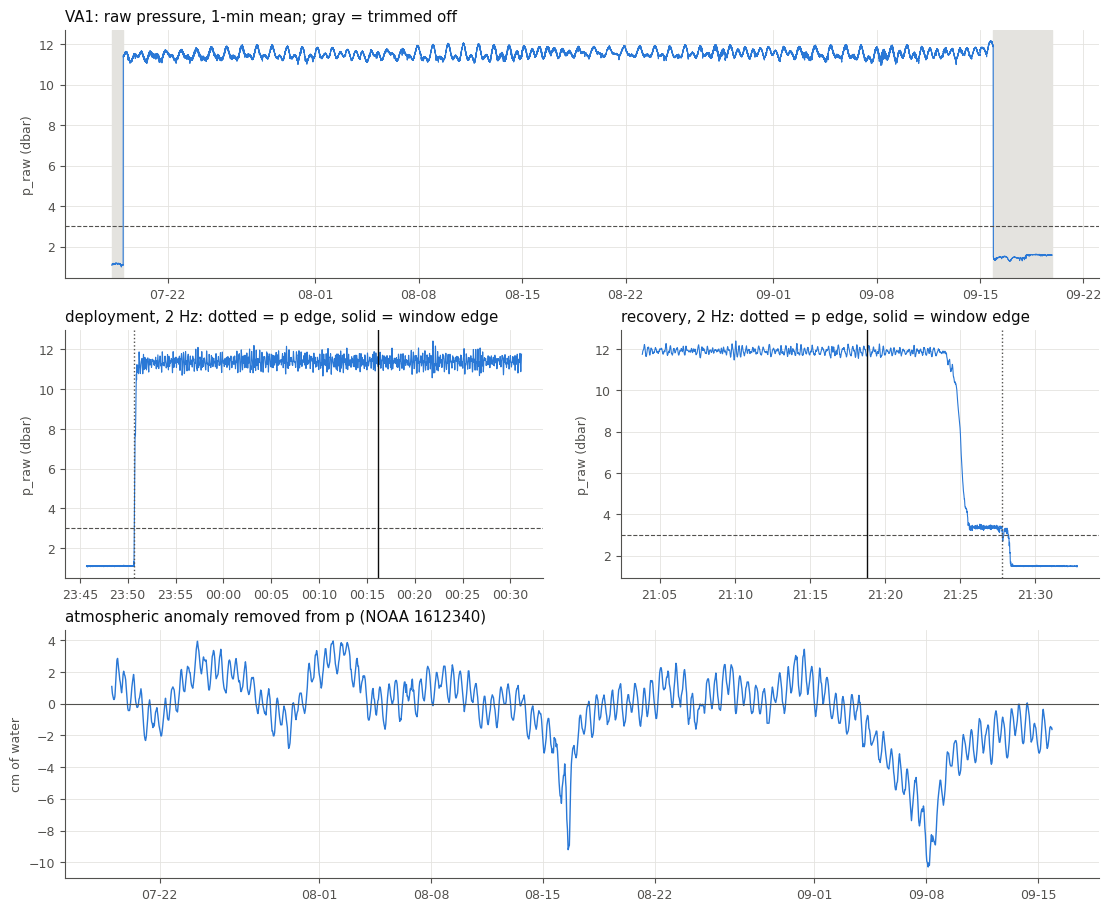

In [10]:
##-----figure: trim window + atmospheric correction-----##
# top row: whole raw record at 1-min means (10.7 M points is too many to draw); gray = cut
p1 = pd.Series(p_raw, index=t).resample("1min").mean()
fig = plt.figure(figsize=(11, 9), constrained_layout=True)
gs = fig.add_gridspec(3, 2)

ax = fig.add_subplot(gs[0, :])
ax.plot(p1.index, p1.values, color=SERIES, lw=0.8)
ax.axvspan(p1.index[0], t_in, color=GRID, zorder=0)
ax.axvspan(t_out, p1.index[-1], color=GRID, zorder=0)
ax.axhline(P_WET, color=INK2, ls="--", lw=0.8)
ax.set_ylabel("p_raw (dbar)")
ax.set_title(f"{sensor_id}: raw pressure, 1-min mean; gray = trimmed off", loc="left", color=INK)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

# middle row: 2 Hz zooms around each end. Dotted = pressure edge (p >= 3 dbar),
# solid = final window edge after the handling cut + buffer
zooms = [(t[i_in] - pd.Timedelta(minutes=5), t_in + pd.Timedelta(minutes=15), t[i_in], t_in, "deployment"),
         (t_out - pd.Timedelta(minutes=15), t[i_out] + pd.Timedelta(minutes=5), t[i_out], t_out, "recovery")]
for j, (a, b, tp, te, lab) in enumerate(zooms):
    ax = fig.add_subplot(gs[1, j])
    w = (t > a) & (t < b)
    ax.plot(t[w], p_raw[w], color=SERIES, lw=0.8)
    ax.axhline(P_WET, color=INK2, ls="--", lw=0.8)
    ax.axvline(tp, color=INK2, ls=":", lw=1)
    ax.axvline(te, color=INK, lw=1)
    ax.set_title(f"{lab}, 2 Hz: dotted = p edge, solid = window edge", loc="left", color=INK)
    ax.set_ylabel("p_raw (dbar)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

# bottom row: the barometric anomaly removed from p, in cm of water (10-min means)
ax = fig.add_subplot(gs[2, :])
a1 = pd.Series(100 * (patm_k - np.median(patm_k)), index=t[keep]).resample("10min").mean()
ax.plot(a1.index, a1.values, color=SERIES, lw=1)
ax.axhline(0, color=INK2, lw=0.8)
ax.set_ylabel("cm of water")
ax.set_title("atmospheric anomaly removed from p (NOAA 1612340)", loc="left", color=INK)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

fig.savefig(fig_dir / f"{sensor_id}_trim.png", dpi=150)
plt.show()

#### 2b. Tide-gauge check of the corrected clock (coarse)
Cross-correlate the sensor's tide (1-min mean water level from `p`) with the NOAA CO-OPS 6-min
water level at Honolulu 1612340. A lag near 0 confirms the clock is UTC with no hour-scale or
time-zone error. It **cannot** resolve seconds: the tide is too slow, and Ewa and Honolulu Harbor
differ in tidal phase by minutes anyway. Seconds-level checking needs the co-located Signature 1000
(VC2 only: wave-band p–p cross-correlation, after the ADCP's own -6 s drift correction). That is
pending the ADCP data.

tide lag VA1 vs Honolulu: -2 min (r = 0.9283); tidal amplitude ratio sensor/gauge = 1.116


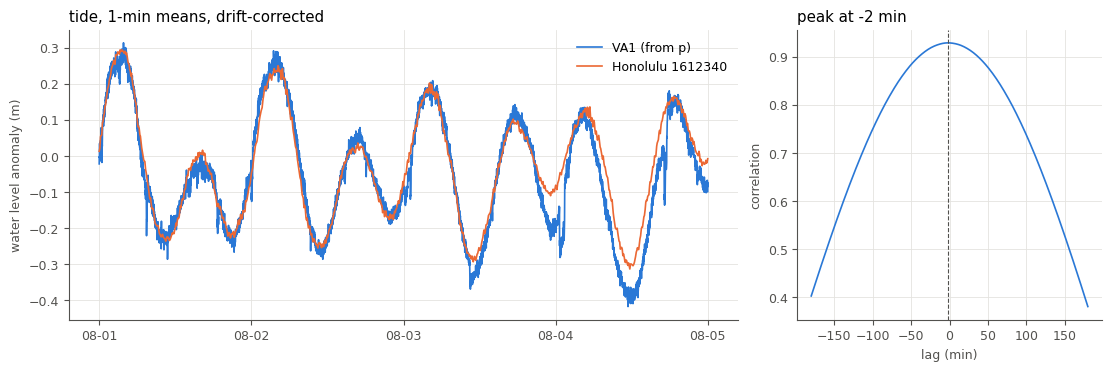

In [11]:
##-----tide-gauge check: coarse clock / time-zone test-----##
# NOAA CO-OPS 1612340 (Honolulu Harbor), 6-min water level relative to MSL, GMT. The API caps
# 6-min requests at 31 days, so fetch in chunks. Cached next to the barometer file.
wl_csv = root / "data" / "metadata" / "noaa_1612340_water_level.csv"
if not wl_csv.exists():
    parts = []
    for a, b in [("20260718", "20260817"), ("20260818", "20260917"), ("20260918", "20260919")]:
        url = ("https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?product=water_level"
               f"&station=1612340&begin_date={a}&end_date={b}&datum=MSL&units=metric"
               "&time_zone=gmt&format=csv&application=4EWA")
        parts.append(pd.read_csv(url, skipinitialspace=True))
    pd.concat(parts).drop_duplicates("Date Time").to_csv(wl_csv, index=False)
wl = pd.read_csv(wl_csv, skipinitialspace=True, parse_dates=["Date Time"]).dropna(subset=["Water Level"])
gauge = wl.set_index("Date Time")["Water Level"]

# water level: hydrostatic p -> m of water (RHO, GRAV from the parameters cell),
# then 1-min means to average out the waves. The gauge's 6-min series is interpolated onto the
# same minutes. Only the tidal variation matters, so both are de-meaned.
eta = pd.Series(out.p.values * 1e4 / (RHO * GRAV), index=out.time.values).resample("1min").mean()
g_i = pd.Series(np.interp(eta.index.values.astype("int64"),
                          gauge.index.values.astype("int64"), gauge.values), index=eta.index)
eta_a, g_a = eta - eta.mean(), g_i - g_i.mean()

# correlation at lags of -3 h to +3 h in 1-min steps. Lag L compares the sensor at t with the gauge at
# t - L. The peak should sit at ~0; a +/-600 min peak would mean a Hawaii-time clock.
lags = np.arange(-180, 181)
r = np.array([eta_a.corr(g_a.shift(L)) for L in lags])
best = lags[np.argmax(r)]
print(f"tide lag {sensor_id} vs Honolulu: {best:+d} min (r = {r.max():.4f}); "
      f"tidal amplitude ratio sensor/gauge = {eta_a.std() / g_a.std():.3f}")
out.attrs["qc_clock_tide_lag_min"] = int(best)

# figure: left = 4-day overlay, right = correlation vs lag
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True,
                        gridspec_kw={"width_ratios": [2.2, 1]})
w = slice("2026-08-01", "2026-08-04")
axs[0].plot(eta_a[w].index, eta_a[w].values, color="#2a78d6", lw=1.2, label=f"{sensor_id} (from p)")
axs[0].plot(g_a[w].index, g_a[w].values, color="#eb6834", lw=1.2, label="Honolulu 1612340")
axs[0].set_ylabel("water level anomaly (m)")
axs[0].set_title("tide, 1-min means, drift-corrected", loc="left")
axs[0].legend(frameon=False)
axs[0].xaxis.set_major_locator(mdates.DayLocator())
axs[0].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
axs[1].plot(lags, r, color="#2a78d6", lw=1.2)
axs[1].axvline(best, color="#52514e", ls="--", lw=0.8)
axs[1].set_xlabel("lag (min)")
axs[1].set_ylabel("correlation")
axs[1].set_title(f"peak at {best:+d} min", loc="left")
fig.savefig(fig_dir / f"{sensor_id}_clock_tide.png", dpi=150)
plt.show()

In [12]:
##-----save-----##
# zlib compression on every data variable (level 4: good size/speed tradeoff; ~0.18 GB per sensor).
# time is listed explicitly: replacing the coordinate (drift correction) dropped its compression
# settings, and uncompressed int64 time adds ~70 MB.
# Written to data/processed/qc/{sensor}_trim.nc: clock-corrected AND trimmed (sections 1 + 2).
# The untrimmed file in data/processed/ is untouched.
enc = {v: {"zlib": True, "complevel": 4} for v in out.data_vars}
enc["time"] = {"zlib": True, "complevel": 4}
out_path = qc_dir / f"{sensor_id}_trim.nc"
out.to_netcdf(out_path, encoding=enc)
print(f"saved {out_path}  ({out_path.stat().st_size / 1e9:.2f} GB)")

saved /Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/data/processed/qc/VA1_trim.nc  (0.18 GB)


### 3. Beam Quality masks
 - Correlation: the lab (NEVAEWA/Nortek_Vector_PUV_Pipeline) NaNs velocity where the minimum beam
   correlation is below 70% (Nortek recommendation; `corrMin = 70`, `valid_corr` in
   `L1_raw_to_qc/puv_channel_qc.m`). Also check low amplitude/SNR (burial, fouling, out of water).
   Watch for progressive correlation loss, which can be biofouling in warm water (CAT21A example
   in the lab's `PIPELINE_NOTES.md`).
 - Gate per channel, not per row. The lab's 2026-07 channel-decoupling rework lets pressure
   and velocity fail independently (`L1_raw_to_qc/puv_channel_qc.m`,
   `docs/OUTSTANDING_channel_decoupling.md`).
 - Report the % flagged per sensor and per hour, and plot it against time and Hs.

#### 3a. Correlation gate + amplitude diagnostic

Input is `out` from section 2 (clock-corrected, trimmed, atmosphere removed).
1. **Correlation gate (applied).** A velocity sample is kept only if **all three** beams have
   `corr >= CORR_MIN` (70 %), the lab's `valid_corr = min(corr) >= corrMin`. The gate is per
   sample, not per velocity component: in the instrument frame, u, v and w are each a combination
   of all three beam velocities, so one bad beam corrupts all three. Failed samples become NaN in
   u, v, w. Pressure and temperature are not touched (channel decoupling).
2. **Amplitude / SNR (diagnostic, not applied).** The lab does not gate on amplitude. Here
   `SNR ≈ 0.43 dB/count × (amp − noise floor)`, with the noise floor per beam taken as the median
   pre-deployment in-air amplitude. Samples where any beam is below `SNR_MIN` are stored in
   `vel_low_snr` and reported, but velocity is not NaN'd unless `APPLY_SNR = True`. Turn it on only
   if the figure shows low SNR catching something the correlation gate misses (e.g. burial).
3. **Diagnostics.** % flagged per hour against time and against `Hs_p`; daily median correlation
   and amplitude per beam (a steady decline = biofouling or burial); correlation histograms.
   `Hs_p = 4 × std` of bed pressure after a 5-min high-pass, in m of water. It is **not**
   corrected for depth attenuation, so it underestimates Hs (more for short waves). It is only used
   to see whether the flag rate tracks wave energy (bubbles, sediment, orbital velocities near the
   velocity range).
4. **Save** `{sensor}_beam.nc`.

In [13]:
##-----beam quality: correlation gate + amplitude diagnostic-----##
corr = out["corr"].values                 # (beam, time), %
amp  = out["amp"].values.astype(float)    # (beam, time), counts

# correlation, per beam, then per sample: all three beams must pass
corr_ok_beam = corr >= CORR_MIN
vel_ok = corr_ok_beam.all(axis=0)

# amplitude -> approximate SNR. Noise floor per beam = median in-air amplitude before deployment
# (`pre` from section 2: p_raw < P_AIR, > 5 min before the splash), where no echo comes back.
noise = np.median(ds["amp"].values[:, pre], axis=1)
snr = AMP_DB_PER_COUNT * (amp - noise[:, None])
low_snr = (snr < SNR_MIN).any(axis=0)

bad = ~vel_ok | (low_snr if APPLY_SNR else False)

# new dataset: u, v, w NaN'd where bad; everything else (p, temp, corr, amp, ...) as in `out`.
# `out` itself is left untouched, so re-running this cell with other thresholds is safe.
bq = out.copy()
keep_da = xr.DataArray(~bad, dims="time")
for c in ["u", "v", "w"]:
    bq[c] = out[c].where(keep_da)
    bq[c].attrs = dict(out[c].attrs, beam_qc=f"NaN where min beam corr < {CORR_MIN} %"
                       + (f" or any beam SNR < {SNR_MIN} dB" if APPLY_SNR else ""))
bq["vel_corr_ok"] = xr.DataArray(vel_ok, dims="time",
    attrs={"long_name": f"all three beam correlations >= {CORR_MIN} %"})
bq["vel_low_snr"] = xr.DataArray(low_snr, dims="time",
    attrs={"long_name": f"any beam SNR < {SNR_MIN} dB", "applied": str(APPLY_SNR)})
bq.attrs.update({
    "qc_beam_corr_min_pct": CORR_MIN,
    "qc_beam_snr_min_db": SNR_MIN,
    "qc_beam_snr_applied": str(APPLY_SNR),
    "qc_beam_amp_noise_floor_counts": ", ".join(f"{x:.0f}" for x in noise),
    "qc_beam_vel_flagged_pct": float(100 * bad.mean()),
})

# gaps: lengths of consecutive flagged runs (matters for how despiking/interpolation treats them)
g0, g1 = runs(bad)
glen = g1 - g0 + 1

n = bad.size
print(f"{sensor_id}: velocity flagged in {100 * bad.mean():.2f} % of {n:,} in-water samples")
for b in range(3):
    print(f"  beam {b + 1}: corr < {CORR_MIN} % in {100 * (~corr_ok_beam[b]).mean():.2f} %, "
          f"median corr {np.median(corr[b]):.0f} %, noise floor {noise[b]:.0f} counts, "
          f"median SNR {np.median(snr[b]):.1f} dB")
print(f"  low SNR (< {SNR_MIN} dB, any beam): {100 * low_snr.mean():.2f} % "
      f"({100 * (low_snr & vel_ok).mean():.2f} % NOT already caught by correlation) -> "
      f"{'applied' if APPLY_SNR else 'diagnostic only'}")
if glen.size:
    print(f"  flagged runs: {glen.size:,}; median {np.median(glen):.0f} samples, "
          f"{100 * (glen <= 4).mean():.0f} % are <= 4 samples (2 s), longest {glen.max():,} "
          f"samples ({glen.max() / float(ds.attrs['fs']) / 60:.1f} min)")

VA1: velocity flagged in 17.65 % of 10,173,906 in-water samples
  beam 1: corr < 70 % in 0.92 %, median corr 97 %, noise floor 46 counts, median SNR 33.1 dB


  beam 2: corr < 70 % in 3.14 %, median corr 95 %, noise floor 46 counts, median SNR 30.5 dB
  beam 3: corr < 70 % in 16.03 %, median corr 93 %, noise floor 46 counts, median SNR 27.1 dB
  low SNR (< 5.0 dB, any beam): 5.44 % (0.06 % NOT already caught by correlation) -> diagnostic only
  flagged runs: 308,751; median 2 samples, 80 % are <= 4 samples (2 s), longest 2,788 samples (23.2 min)


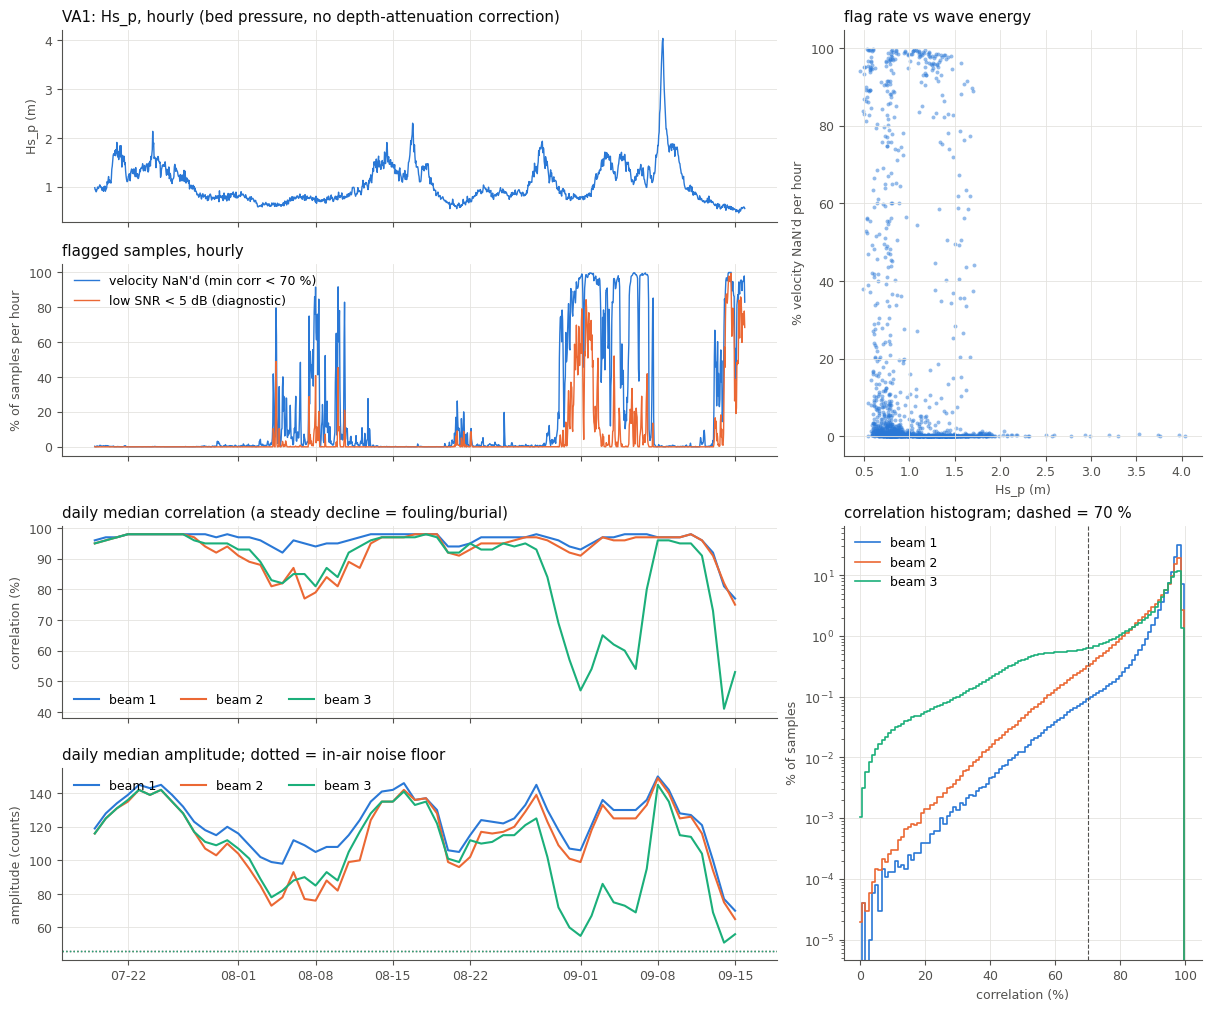

hourly flag rate: median 0.62 %, max 99.8 % (2026-09-14 15:00:00); corr with Hs_p r = -0.14


In [14]:
##-----figure: beam quality over the deployment-----##
tq = pd.DatetimeIndex(bq.time.values)
fs = float(ds.attrs["fs"])

# Hs_p: 4 * std of bed pressure after a 5-min high-pass (removes tide), per hour, m of water.
# NOT corrected for depth attenuation: a wave-energy proxy only.
p_s = pd.Series(out.p.values.astype(float), index=tq)
p_hp = p_s - p_s.rolling(int(300 * fs), center=True, min_periods=int(60 * fs)).mean()
hs_p = 4 * p_hp.resample("1h").std() * 1e4 / (RHO * GRAV)

flag_h = 100 * pd.Series(bad, index=tq).resample("1h").mean()
snr_h  = 100 * pd.Series(low_snr, index=tq).resample("1h").mean()
corr_d = pd.DataFrame(corr.T, index=tq).resample("1D").median()
amp_d  = pd.DataFrame(amp.T, index=tq).resample("1D").median()

fig = plt.figure(figsize=(12, 10), constrained_layout=True)
gs = fig.add_gridspec(4, 3)

# left column: time series, shared x
ax0 = fig.add_subplot(gs[0, :2])
ax0.plot(hs_p.index, hs_p.values, color=SERIES, lw=1)
ax0.set_ylabel("Hs_p (m)")
ax0.set_title(f"{sensor_id}: Hs_p, hourly (bed pressure, no depth-attenuation correction)",
              loc="left", color=INK)

ax1 = fig.add_subplot(gs[1, :2], sharex=ax0)
ax1.plot(flag_h.index, flag_h.values, color=BEAM_COLORS[0], lw=1,
         label=f"velocity NaN'd (min corr < {CORR_MIN} %)")
ax1.plot(snr_h.index, snr_h.values, color=BEAM_COLORS[1], lw=1,
         label=f"low SNR < {SNR_MIN:g} dB ({'applied' if APPLY_SNR else 'diagnostic'})")
ax1.set_ylabel("% of samples per hour")
ax1.set_title("flagged samples, hourly", loc="left", color=INK)
ax1.legend(frameon=False, loc="upper left")

ax2 = fig.add_subplot(gs[2, :2], sharex=ax0)
for b in range(3):
    ax2.plot(corr_d.index, corr_d[b].values, color=BEAM_COLORS[b], lw=1.5, label=f"beam {b + 1}")
ax2.set_ylabel("correlation (%)")
ax2.set_title("daily median correlation (a steady decline = fouling/burial)", loc="left", color=INK)
ax2.legend(frameon=False, loc="lower left", ncol=3)

ax3 = fig.add_subplot(gs[3, :2], sharex=ax0)
for b in range(3):
    ax3.plot(amp_d.index, amp_d[b].values, color=BEAM_COLORS[b], lw=1.5, label=f"beam {b + 1}")
    ax3.axhline(noise[b], color=BEAM_COLORS[b], ls=":", lw=1)
ax3.set_ylabel("amplitude (counts)")
ax3.set_title("daily median amplitude; dotted = in-air noise floor", loc="left", color=INK)
ax3.legend(frameon=False, loc="upper left", ncol=3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
for a in (ax0, ax1, ax2):
    a.tick_params(labelbottom=False)

# right column: flag rate vs wave energy, and correlation histograms
ax4 = fig.add_subplot(gs[:2, 2])
both = pd.concat([hs_p.rename("hs"), flag_h.rename("f")], axis=1).dropna()
ax4.scatter(both.hs, both.f, s=8, color=SERIES, alpha=0.5, lw=0)
ax4.set_xlabel("Hs_p (m)")
ax4.set_ylabel("% velocity NaN'd per hour")
ax4.set_title("flag rate vs wave energy", loc="left", color=INK)

ax5 = fig.add_subplot(gs[2:, 2])
bins = np.arange(0, 102)
for b in range(3):
    h = np.bincount(corr[b], minlength=101)[:101]
    ax5.step(bins[:-1], 100 * h / h.sum(), where="mid", color=BEAM_COLORS[b], lw=1.2,
             label=f"beam {b + 1}")
ax5.axvline(CORR_MIN, color=INK2, ls="--", lw=0.8)
ax5.set_yscale("log")
ax5.set_xlabel("correlation (%)")
ax5.set_ylabel("% of samples")
ax5.set_title(f"correlation histogram; dashed = {CORR_MIN} %", loc="left", color=INK)
ax5.legend(frameon=False, loc="upper left")

fig.savefig(fig_dir / f"{sensor_id}_beam.png", dpi=150)
plt.show()
print(f"hourly flag rate: median {flag_h.median():.2f} %, max {flag_h.max():.1f} % "
      f"({flag_h.idxmax()}); corr with Hs_p r = {both.hs.corr(both.f):.2f}")

In [15]:
##-----save-----##
# same compression as section 2. u, v, w are NaN'd where flagged; the unmasked values are in
# {sensor}_trim.nc. Flags are saved so the mask can be re-derived or combined later.
enc = {v: {"zlib": True, "complevel": 4} for v in bq.data_vars}
enc["time"] = {"zlib": True, "complevel": 4}
out_path = qc_dir / f"{sensor_id}_beam.nc"
bq.to_netcdf(out_path, encoding=enc)
print(f"saved {out_path}  ({out_path.stat().st_size / 1e9:.2f} GB)")

saved /Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/data/processed/qc/VA1_beam.nc  (0.17 GB)


### 4. Despiking
 - Order: despike in the instrument frame, before rotation. Rotation smears a spike on one beam into all components.
 - Method: Goring & Nikora (2002) phase-space thresholding, modified by Wahl (2003). Mori, Suzuki & Kakuno (2007) is the variant for bubbly/wave conditions. dolfyn 1.3.0 has dolfyn.adv.clean.GN2002, spike_thresh, range_limit, clean_fill (present in `dolf_env` only; in this notebook's `analysiz` kernel `import dolfyn` fails on scipy's removed `cumtrapz`).
 - At 2 Hz in waves, GN2002's "universal threshold" assumes a spiky turbulence signal sampled fast. Real orbital-velocity crests can be flagged. Apply it to a residual (detrended or high-passed about the wave-band signal, or per short window), or tune the threshold. Inspect flagged points overlaid on raw data during the largest-wave hours.
 - Replace only short runs (interpolate ≲ a few samples). Leave longer gaps as NaN. Record % replaced per segment; the lab drops segments with >10% NaN before spectra (nanMaxFrac).
 - Surf-zone ADV QC context: Elgar, Raubenheimer & Guza (2001, 2005) and Feddersen (2010).

#### 4a. Universal threshold on a wave-free residual (dolfyn GN2002 as an option)

**Why not phase-space (GN2002 / Mori 2007) directly.** Tested on VC1 hours of small, moderate and
large waves:
- GN2002's third ellipse (x vs d²x) has no real solution here. Waves make x and d²x strongly
  correlated (d²x ≈ −(ωΔt)²x), so the rotated-ellipse equations give a negative axis² and the test
  flags points in the middle of the cloud.
- The Mori et al. (2007) 3-D ellipsoid (principal axes, robust scales) avoids that, but at 2 Hz it
  still flags wave crests: 12 % of u in a moderate-wave hour (07-30 11:00), and its iterations
  removed whole wave groups.

The same holds for dolfyn's own `GN2002` on raw u (VC1, 09-06 to 09-09): 75 % of its flags sit on
wave crests (background 12 %). On the residual below, 39 % do, and 35 % of its flags have a
correlation dip (background 9 %).

**What is done instead** (the "residual about the wave-band signal" from the notes above; dolfyn
is used for detection and filling):
1. **Residual.** `r_i = x_i − cubic through x_{i−2}, x_{i−1}, x_{i+1}, x_{i+2}`
   = `(x_{i−2} − 4x_{i−1} + 6x_i − 4x_{i+1} + x_{i+2}) / 6`. It keeps a one-sample spike at full
   height but only ~2 % of a 5-s wave and ~0.2 % of a 10-s wave, so the wave signal no longer
   sets the threshold.
2. **Detection, `DESPIKE_METHOD = "GN2002"` (alternative).** `dolfyn.adv.clean.GN2002` (Goring &
   Nikora 2002 3-D phase space with the Wahl 2003 correction) is run on the residual, in 1-h blocks
   (`GN_NPT`). Its thresholds are fixed (universal threshold, plain std) and cannot be tuned.
   **`DESPIKE_METHOD = "universal"`** (chosen) is tunable: flag `|r| > DESPIKE_K · sqrt(2 ln n) · σ_r` (the GN2002 universal threshold,
   n = 7200 samples per hour), with `σ_r = 1.4826 · MAD(r)` per clock hour (robust, as in Wahl 2003).
   `DESPIKE_K = 1.5` (6.3 σ), not 1. On VC1 the residual is heavy-tailed (turbulence, steep
   crests). The 4–6 σ flags barely differ from background in correlation dips, and at every
   severity ~45 % of u-triggered flags sit on wave crests. There is no clean break, so K is a
   judgment call: 1.5 does not change the crest share, it cuts the number of flags ~4× and the
   u-crest removals ~6×. The severity table and the u-skewness check below show this per sensor.
   Only local maxima of `|r|` are flagged, because a spike of height s also puts −2/3 s into
   the residual of each neighbour.
3. **Per sample, all components.** Each of u, v, w is tested. A sample flagged in any component
   is removed from all three, for the same reason as the beam gate: each component mixes all
   three beams.
4. **Passes.** Up to `DESPIKE_MAX_ITER` (2): flagged samples are replaced by a spline and the
   residual is recomputed, which catches spike pairs. More passes cascade up the steep fronts of
   breaking waves.
5. **Gaps.** Before the residual is computed, short beam-mask gaps are temporarily spline-filled so
   their neighbours can be tested. Hours with less than `SEG_MIN_VALID` valid velocity (e.g. VC1's
   last days) are not despiked.
6. **Fill.** Spikes and beam-mask NaNs become NaN. Runs of up to `MAX_FILL` samples (2 s) are then
   filled with `dolfyn.adv.clean.clean_fill` (cubic, 12 points either side). Its `maxgap` also fills
   the first `MAX_FILL` samples of every *longer* gap (xarray's `limit`), so those are set back to
   NaN. Longer gaps stay NaN. `vel_spike` and `vel_filled` record
   which samples were changed.
7. **Per-hour table** (the lab's 1-h segments, aligned to HH:00): % spikes, % filled, % NaN left, and
   `seg_ok` = NaN ≤ `NAN_MAX_FRAC` (10 %).

**Checks printed below:**
- Are spike flags enriched in samples with a correlation dip (min corr < 90 %)? If yes, they are
  instrument artifacts (bubbles, sediment), not noise. The check is split by wave-height tercile.
- Does the wave-band (0.05–0.3 Hz) variance of u survive? The ratio after/before should be ≈ 1.
  The high-frequency band (0.5–1 Hz) is where removing spikes should show.
- Are crests clipped? Hourly skewness of u after − before. Variance cannot see clipped crests, and
  skewness matters for sediment transport.
- Zoom figure: the flagged points in the largest-wave hour and in a calm hour, overlaid on the data.

In [16]:
##-----despiking: dolfyn GN2002 (or universal threshold) on a wave-free residual-----##

comps = ["u", "v", "w"]
tq = pd.DatetimeIndex(bq.time.values)
fs = float(ds.attrs["fs"])
seg_n = int(3600 * fs)                                   # samples per 1-h segment
hcode = np.asarray((tq - tq[0].floor("1h")) // pd.Timedelta(hours=1))   # clock-hour index per sample
n = tq.size
K4 = np.array([1, -4, 6, -4, 1]) / 6.0                   # x_i minus cubic through its 2+2 neighbours

def resid(x):
    # NaN wherever the 5-sample stencil touches a NaN (i.e. next to a gap that was not filled)
    r = np.convolve(x, K4, mode="same")
    r[:2] = r[-2:] = np.nan
    return r

def hourly_scale(r):
    # robust std per clock hour: 1.4826 * MAD (NaN-aware)
    s = pd.Series(r)
    med = s.groupby(hcode).transform("median")
    return 1.4826 * (s - med).abs().groupby(hcode).transform("median").values

def fill_short(x, max_len):
    """dolfyn clean_fill (cubic, 12 points either side) of NaN runs <= max_len samples.
    clean_fill's maxgap is passed to xarray's interpolate_na(limit=...), which ALSO fills the first
    max_len samples of every longer gap, so those are set back to NaN here.
    Returns the filled copy and a mask of the samples that were filled."""
    nan = np.isnan(x)
    g0, g1 = runs(nan)
    L = g1 - g0 + 1
    g0, L = g0[L > max_len], L[L > max_len]
    long_gap = np.zeros(x.size, bool)
    long_gap[np.repeat(g0, L) + (np.arange(L.sum()) - np.repeat(np.cumsum(L) - L, L))] = True
    out = dclean.clean_fill(xr.DataArray(x.copy()), np.zeros(x.size, bool),
                            npt=12, method="cubic", maxgap=max_len).values
    out[long_gap] = np.nan
    return out, nan & np.isfinite(out)

X0 = {c: bq[c].values.astype(float) for c in comps}    # beam-masked velocities
valid = np.isfinite(X0["u"]) & np.isfinite(X0["v"]) & np.isfinite(X0["w"])
hour_valid = pd.Series(valid).groupby(hcode).transform("mean").values
testable = valid & (hour_valid >= SEG_MIN_VALID)
lam = DESPIKE_K * np.sqrt(2 * np.log(seg_n))
assert DESPIKE_METHOD in ("GN2002", "universal"), DESPIKE_METHOD

spike = np.zeros(n, bool)
severity = np.zeros(n)                                       # first pass: max over u, v, w of |r| / sigma
trigger = np.zeros(n, int)                                   # component with that max (0 u, 1 v, 2 w)
Xt = {c: fill_short(X0[c], MAX_FILL)[0] for c in comps}     # temporary fill, so gap neighbours are tested
untested = testable & ~np.isfinite(resid(Xt["u"]))
n_pass = []
for it in range(DESPIKE_MAX_ITER):
    new_ = np.zeros(n, bool)
    for c in comps:
        r = resid(Xt[c])
        a = np.abs(r)
        a0 = np.nan_to_num(a)
        peak = (a0 >= np.r_[0, a0[:-1]]) & (a0 >= np.r_[a0[1:], 0])
        z = np.where(peak & testable, a / hourly_scale(r), 0)
        if it == 0:
            k = np.nan_to_num(z) > severity
            severity[k], trigger[k] = z[k], comps.index(c)
        if DESPIKE_METHOD == "GN2002":
            # dolfyn GN2002 skips any block containing a NaN, so untestable residuals are set to 0
            # ("no spike"). Only residual peaks are kept: a spike of height s also puts -2/3 s into
            # the residual of each neighbour.
            hit = dclean.GN2002(xr.DataArray(np.where(np.isfinite(r), r, 0.0)), npt=GN_NPT)
            hit &= peak & testable & np.isfinite(r)
        else:
            hit = z > lam
        new_ |= hit & ~spike
    n_pass.append(int(new_.sum()))
    if not new_.any():
        break
    spike |= new_
    for c in comps:                                          # replace and re-test
        x = X0[c].copy()
        x[spike] = np.nan
        Xt[c] = fill_short(x, MAX_FILL)[0]

method_str = (f"dolfyn.adv.clean.GN2002(npt={GN_NPT}) on 4th-difference residual" if DESPIKE_METHOD == "GN2002"
              else f"4th-difference residual > {DESPIKE_K:g} * sqrt(2 ln {seg_n}) * hourly MAD")

# final: spikes -> NaN, then fill short runs (spikes and beam-mask gaps alike)
dsp = bq.copy()
for c in comps:
    x = X0[c].copy()
    x[spike] = np.nan
    xf, filled = fill_short(x, MAX_FILL)                     # same NaN pattern in u, v, w
    dsp[c] = xr.DataArray(xf.astype("float32"), dims="time",
                          attrs=dict(bq[c].attrs, despike=(
                              f"{method_str} -> NaN; NaN runs <= {MAX_FILL} samples filled with "
                              "dolfyn clean_fill (cubic)")))
dsp["vel_spike"] = xr.DataArray(spike, dims="time", attrs={"long_name": "velocity spike removed"})
dsp["vel_filled"] = xr.DataArray(filled, dims="time",
    attrs={"long_name": f"velocity filled by dolfyn clean_fill, cubic (NaN run <= {MAX_FILL} samples)"})

# per-hour table (the lab's 1-h spectral segments, aligned to HH:00)
nan_left = np.isnan(dsp["u"].values)
seg = (pd.DataFrame({"spike": spike, "filled": filled, "nan": nan_left}, index=tq)
         .resample("1h").mean() * 100)
seg["ok"] = seg["nan"] <= 100 * NAN_MAX_FRAC
dsp = dsp.assign_coords(hour=seg.index.values)
dsp["seg_spike_pct"]  = ("hour", seg["spike"].values.astype("float32"))
dsp["seg_filled_pct"] = ("hour", seg["filled"].values.astype("float32"))
dsp["seg_nan_pct"]    = ("hour", seg["nan"].values.astype("float32"))
dsp["seg_ok"]         = ("hour", seg["ok"].values)
dsp["seg_ok"].attrs["long_name"] = f"1-h segment has <= {100 * NAN_MAX_FRAC:g} % NaN velocity"
dsp.attrs.update({
    "qc_despike_method": method_str + "; residual = x_i minus cubic through 2+2 neighbours; union over u, v, w",
    "qc_despike_k": DESPIKE_K if DESPIKE_METHOD == "universal" else "n/a (GN2002)",
    "qc_despike_fill": f"dolfyn.adv.clean.clean_fill(npt=12, method='cubic', maxgap={MAX_FILL}); longer gaps re-NaN'd",
    "qc_despike_max_iter": DESPIKE_MAX_ITER,
    "qc_despike_max_fill_samples": MAX_FILL,
    "qc_despike_seg_min_valid": SEG_MIN_VALID,
    "qc_despike_spike_pct": float(100 * spike.mean()),
    "qc_despike_filled_pct": float(100 * filled.mean()),
    "qc_seg_nan_max_frac": NAN_MAX_FRAC,
    "qc_seg_ok_pct": float(100 * seg["ok"].mean()),
})

print(f"{sensor_id}: {method_str}; passes: {n_pass} new spikes")
print(f"  spikes removed {100 * spike.mean():.2f} % | filled {100 * filled.mean():.2f} % "
      f"(spikes + beam-mask gaps <= {MAX_FILL} samples) | NaN left {100 * nan_left.mean():.2f} %")
print(f"  not despiked: {100 * (valid & ~testable).mean():.2f} % (hours < {100 * SEG_MIN_VALID:g} % valid), "
      f"untestable next to long gaps {100 * untested.mean():.2f} %")
print(f"  1-h segments: {seg['ok'].sum()} of {len(seg)} pass NaN <= {100 * NAN_MAX_FRAC:g} % "
      f"(failing: {', '.join(f'{h:%m-%d %H}h' for h in seg.index[~seg['ok']][:8])}"
      f"{' ...' if (~seg['ok']).sum() > 8 else ''})")

VA1: 4th-difference residual > 1.5 * sqrt(2 ln 7200) * hourly MAD; passes: [15388, 5612] new spikes
  spikes removed 0.21 % | filled 4.15 % (spikes + beam-mask gaps <= 4 samples) | NaN left 13.70 %
  not despiked: 2.47 % (hours < 50 % valid), untestable next to long gaps 0.30 %
  1-h segments: 1131 of 1414 pass NaN <= 10 % (failing: 08-04 04h, 08-04 09h, 08-04 10h, 08-04 11h, 08-05 01h, 08-06 14h, 08-06 15h, 08-07 09h ...)


correlation-dip check (min corr < 90 %):
  Hs_p low  (0.46-0.80 m): spikes 0.38 % | corr dip at spikes  97.5 % vs all 60.0 % -> x1.6
  Hs_p mid  (0.80-1.17 m): spikes 0.13 % | corr dip at spikes  63.4 % vs all 25.7 % -> x2.5
  Hs_p high (1.17-4.04 m): spikes 0.28 % | corr dip at spikes  50.8 % vs all 12.8 % -> x4.0


by severity (|r| / robust sigma; universal threshold K = 1 is 4.21, K = 1.5 is 6.32); method universal; background corr dip 31.5 %, crest 7.4 %:


   0.00-4.21 : 45.856 % of samples | corr dip 31.5 % | trigger u/v/w 33 / 33 / 34 % | u-flags on crest 10 % | removed 0 %
   4.21-5    : 0.356 % of samples | corr dip 57.9 % | trigger u/v/w 23 / 22 / 55 % | u-flags on crest 15 % | removed 2 %
   5.00-6.3  : 0.227 % of samples | corr dip 61.5 % | trigger u/v/w 21 / 20 / 59 % | u-flags on crest 17 % | removed 19 %
   6.30-8    : 0.097 % of samples | corr dip 65.5 % | trigger u/v/w 19 / 19 / 62 % | u-flags on crest 18 % | removed 99 %
   8.00-12   : 0.048 % of samples | corr dip 67.6 % | trigger u/v/w 16 / 18 / 66 % | u-flags on crest 21 % | removed 100 %


  12.00-inf  : 0.008 % of samples | corr dip 63.6 % | trigger u/v/w 6 / 10 / 83 % | u-flags on crest 36 % | removed 100 %


u variance after/before, 772 gap-free hours: wave band 0.05-0.3 Hz median 1.0000 (min 0.9967); 0.5-1 Hz median 0.993 (min 0.797)
  largest-wave gap-free hour 2026-09-08 11:00:00 (Hs_p 4.04 m): wave band 0.9979, 0.5-1 Hz 0.853
u skewness after - before: median -0.0000, worst 0.0090 (hour 2026-09-08 08:00:00, skew 0.41); largest-wave 10 % of hours median -0.0005 (typical skew there 0.34)


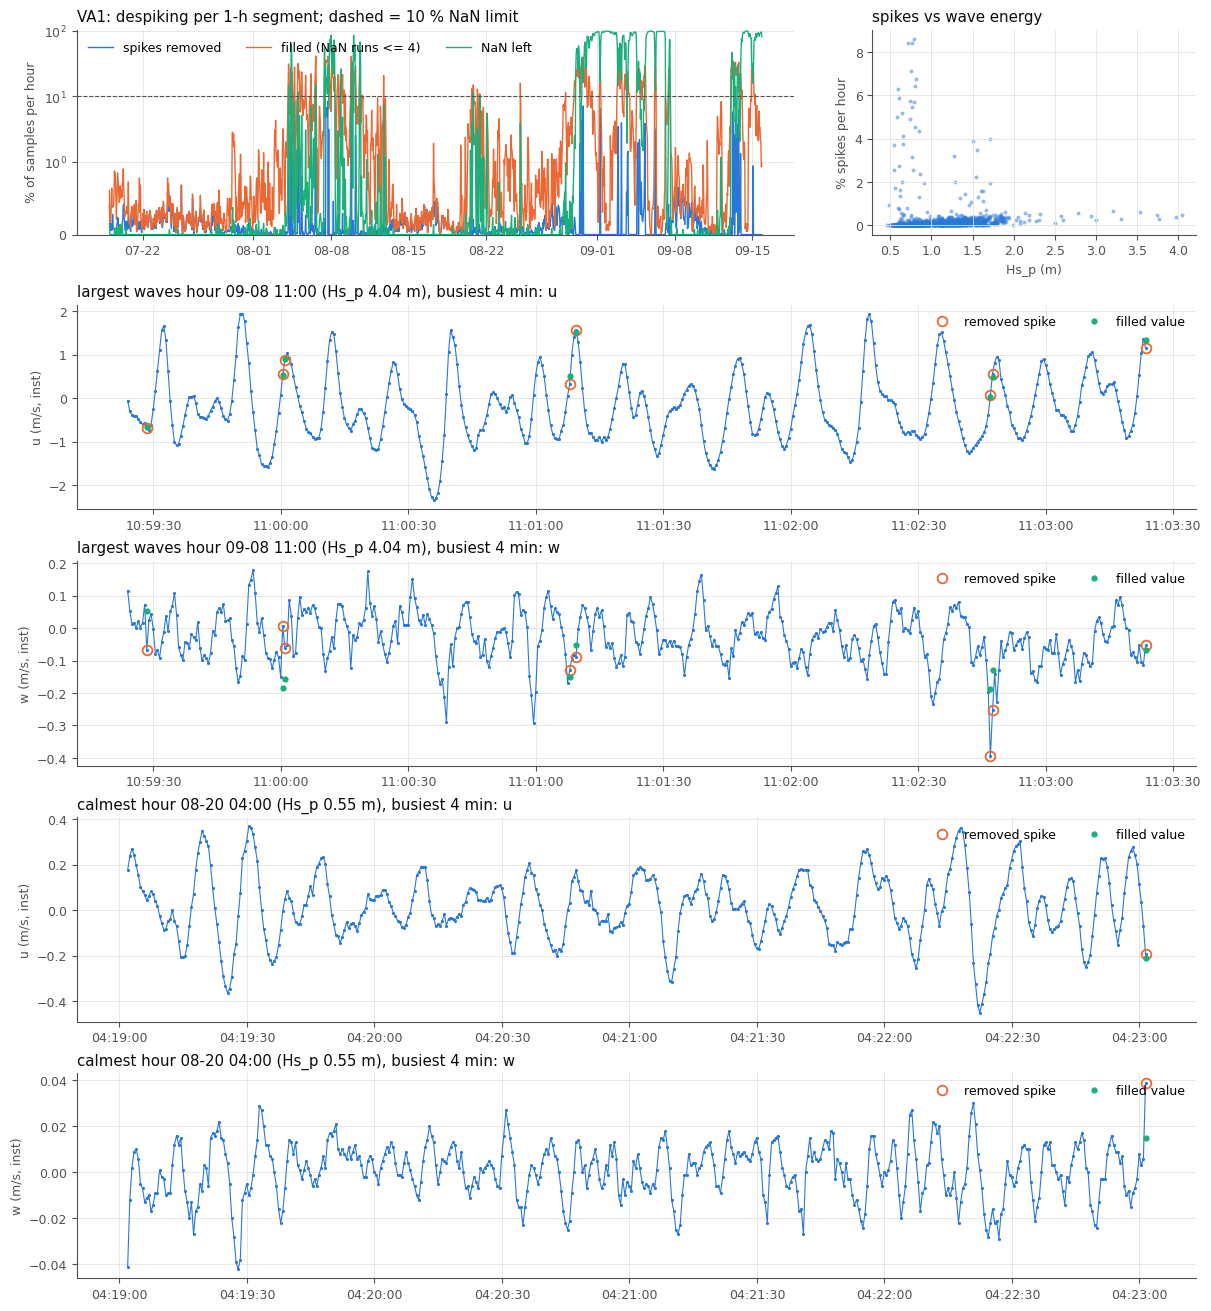

In [17]:
##-----despiking checks + figure-----##
# 1. are spikes instrument artifacts? Compare how often a correlation dip (min beam corr < 90 %)
#    occurs at spike samples vs at all tested samples, per wave-height tercile. Enrichment >> 1
#    means the flags sit on bad pings (bubbles, sediment); ~1 would mean noise-tail false positives.
corr_min = bq["corr"].min("beam").values
lowc = corr_min < 90
hs_s = hs_p.reindex(tq.floor("1h")).values               # hourly Hs_p from section 3, per sample
terc = pd.qcut(hs_p.dropna(), 3, labels=["low", "mid", "high"])
terc_s = terc.reindex(tq.floor("1h")).values
print("correlation-dip check (min corr < 90 %):")
for lab in ["low", "mid", "high"]:
    m = testable & (terc_s == lab)
    p_all, p_sp = lowc[m].mean(), lowc[m & spike].mean()
    print(f"  Hs_p {lab:4s} ({hs_p.dropna()[terc == lab].min():.2f}-{hs_p.dropna()[terc == lab].max():.2f} m): "
          f"spikes {100 * spike[m].mean():.2f} % | corr dip at spikes {100 * p_sp:5.1f} % "
          f"vs all {100 * p_all:4.1f} % -> x{p_sp / p_all:.1f}")

# 1b. the same by severity (first pass, |r| / sigma over all tested samples) plus which component
#     triggered, and how often a u-triggered flag sits on a wave crest/trough (|u anomaly| > 1.5
#     hourly std, residual of the same sign), and how much of each bin the current method removed.
#     Use this to judge DESPIKE_METHOD / DESPIKE_K.
u_an = (pd.Series(X0["u"]).groupby(hcode).transform(lambda s: (s - s.mean()) / s.std())).values
crest = (np.abs(u_an) > 1.5) & (np.sign(resid(fill_short(X0["u"], MAX_FILL)[0])) == np.sign(u_an))
print(f"by severity (|r| / robust sigma; universal threshold K = 1 is 4.21, K = 1.5 is 6.32); "
      f"method {DESPIKE_METHOD}; background corr dip {100 * lowc[testable].mean():.1f} %, "
      f"crest {100 * crest[testable].mean():.1f} %:")
for lo, hi in [(0, 4.21), (4.21, 5), (5, 6.3), (6.3, 8), (8, 12), (12, np.inf)]:
    m = testable & (severity > lo) & (severity <= hi) & (severity > 0)
    mu = m & (trigger == 0)
    print(f"  {lo:5.2f}-{hi:<5.4g}: {100 * m.mean():.3f} % of samples | corr dip {100 * lowc[m].mean():4.1f} % | "
          f"trigger u/v/w {' / '.join(f'{100 * np.mean(trigger[m] == j):.0f}' for j in range(3))} % | "
          f"u-flags on crest {100 * crest[mu].mean():.0f} % | removed {100 * spike[m].mean():.0f} %")

# 2. do the waves survive? Band variance of u after/before despiking, over 1-h segments that are
#    gap-free both before (beam-masked + short fill, no despiking) and after.
u_before = fill_short(X0["u"], MAX_FILL)[0]
u_after = dsp["u"].values.astype(float)
f = np.fft.rfftfreq(seg_n, 1 / fs)
wave_b, hf_b = (f >= 0.05) & (f <= 0.3), (f >= 0.5)
rows = []
for h, g in pd.Series(np.arange(n), index=tq).groupby(tq.floor("1h")):
    ii = g.values
    if ii.size != seg_n or np.isnan(u_before[ii]).any() or np.isnan(u_after[ii]).any():
        continue
    Sb = np.abs(np.fft.rfft(u_before[ii] - u_before[ii].mean())) ** 2
    Sa = np.abs(np.fft.rfft(u_after[ii] - u_after[ii].mean())) ** 2
    rows.append((h, Sa[wave_b].sum() / Sb[wave_b].sum(), Sa[hf_b].sum() / Sb[hf_b].sum(),
                 pd.Series(u_after[ii]).skew() - pd.Series(u_before[ii]).skew(),
                 pd.Series(u_before[ii]).skew()))
vr = pd.DataFrame(rows, columns=["hour", "wave", "hf", "dskew", "skew0"]).set_index("hour")
h_big = hs_p.reindex(vr.index).idxmax()
print(f"u variance after/before, {len(vr)} gap-free hours: wave band 0.05-0.3 Hz median "
      f"{vr.wave.median():.4f} (min {vr.wave.min():.4f}); 0.5-1 Hz median {vr.hf.median():.3f} "
      f"(min {vr.hf.min():.3f})")
print(f"  largest-wave gap-free hour {h_big} (Hs_p {hs_p[h_big]:.2f} m): wave band "
      f"{vr.wave[h_big]:.4f}, 0.5-1 Hz {vr.hf[h_big]:.3f}")
# crest clipping: change in hourly skewness of u (all flags, incl. w-triggered, remove the u value)
big10 = hs_p.reindex(vr.index).nlargest(max(len(vr) // 10, 1)).index
print(f"u skewness after - before: median {vr.dskew.median():+.4f}, worst {vr.dskew.abs().max():.4f} "
      f"(hour {vr.dskew.abs().idxmax()}, skew {vr.skew0[vr.dskew.abs().idxmax()]:.2f}); "
      f"largest-wave 10 % of hours median {vr.dskew[big10].median():+.4f} "
      f"(typical skew there {vr.skew0[big10].median():.2f})")

# 3. figure: hourly rates, spikes vs Hs_p, and 4-min zooms of the busiest windows in the
#    largest-wave hour and in the calmest hour (orange = removed value, aqua = filled value)
seg_spk = seg["spike"]
fig = plt.figure(figsize=(12, 13), constrained_layout=True)
gs = fig.add_gridspec(5, 3)
ax = fig.add_subplot(gs[0, :2])
for col, lab, cc in [("spike", "spikes removed", BEAM_COLORS[0]),
                     ("filled", f"filled (NaN runs <= {MAX_FILL})", BEAM_COLORS[1]),
                     ("nan", "NaN left", BEAM_COLORS[2])]:
    ax.plot(seg.index, seg[col].values, color=cc, lw=1, label=lab)
ax.axhline(100 * NAN_MAX_FRAC, color=INK2, ls="--", lw=0.8)
ax.set_yscale("symlog", linthresh=1)
ax.set_ylim(bottom=0)
ax.set_ylabel("% of samples per hour")
ax.set_title(f"{sensor_id}: despiking per 1-h segment; dashed = {100 * NAN_MAX_FRAC:g} % NaN limit",
             loc="left", color=INK)
ax.legend(frameon=False, loc="upper left", ncol=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

ax = fig.add_subplot(gs[0, 2])
both = pd.concat([hs_p.rename("hs"), seg_spk.rename("s")], axis=1).dropna()
ax.scatter(both.hs, both.s, s=8, color=SERIES, alpha=0.5, lw=0)
ax.set_xlabel("Hs_p (m)")
ax.set_ylabel("% spikes per hour")
ax.set_title("spikes vs wave energy", loc="left", color=INK)

# calm example: lowest Hs_p among clean hours (beam gate removed < 1 %), so it is not taken from
# a degraded stretch such as VC1's last days
beam_h = 100 * (1 - pd.Series(valid, index=tq).resample("1h").mean())
h_calm = hs_p.reindex(beam_h.index[(beam_h < 1) & seg["ok"]]).idxmin()
row = 1
for h, comps_z, lab in [(h_big, ["u", "w"], "largest waves"), (h_calm, ["u", "w"], "calmest")]:
    sl = (tq >= h) & (tq < h + pd.Timedelta(hours=1))
    # busiest 4-min window in that hour
    cnt = pd.Series(spike[sl], index=tq[sl]).rolling("4min").sum()
    z1 = cnt.idxmax(); z0 = z1 - pd.Timedelta(minutes=4)
    zz = (tq > z0) & (tq <= z1)
    for c in comps_z:
        ax = fig.add_subplot(gs[row, :])
        ax.plot(tq[zz], X0[c][zz], color=SERIES, lw=0.8, marker=".", ms=2.5)
        m = zz & spike
        ax.plot(tq[m], X0[c][m], "o", mfc="none", mec=BEAM_COLORS[1], ms=7, mew=1.3, label="removed spike")
        m = zz & filled
        ax.plot(tq[m], dsp[c].values[m], ".", color=BEAM_COLORS[2], ms=7, label="filled value")
        ax.set_ylabel(f"{c} (m/s, inst)")
        ax.set_title(f"{lab} hour {h:%m-%d %H}:00 (Hs_p {hs_p[h]:.2f} m), busiest 4 min: {c}",
                     loc="left", color=INK)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
        ax.legend(frameon=False, loc="upper right", ncol=2)
        row += 1

fig.savefig(fig_dir / f"{sensor_id}_despike.png", dpi=150)
plt.show()

In [18]:
##-----save-----##
# same compression as the earlier sections. u, v, w are despiked and short-gap filled; the
# beam-masked (not despiked) values are in {sensor}_beam.nc. seg_* are per 1-h segment (dim "hour").
enc = {v: {"zlib": True, "complevel": 4} for v in dsp.data_vars}
enc["time"] = {"zlib": True, "complevel": 4}
out_path = qc_dir / f"{sensor_id}_despike.nc"
dsp.to_netcdf(out_path, encoding=enc)
print(f"saved {out_path}  ({out_path.stat().st_size / 1e9:.2f} GB)")

saved /Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/data/processed/qc/VA1_despike.nc  (0.18 GB)


### 5. Rotation to earth/shore-normal
- The internal compass and tilt sensor are in the canister, not the probe head (Nortek Comprehensive
  Manual N3015-030: "The tilt sensor and compass are both located in the housing"; "XYZ and Beam
  velocity data are gathered with respect to the probe head only"). These are cable heads, so the
  internal heading/pitch/roll say nothing about the head and are not used here.
- Rotate head XYZ to earth with the KVH magnetic heading (sensor_notes.csv, the bearing of the +X /
  red arm) + declination, head assumed vertical. Then rotate to shore-normal coordinates, using the
  shore-normal of the sensor's transect (sensor_notes.csv: shoreline bearing W→E minus 90°).
 - Verify the heading physically. This is how the lab caught its 180° errors:
   a. p–u co-spectrum phase ≈ 0 and sign consistent with onshore-propagating swell (south swell at Ewa) [lit/: Elgar & Guza 1985; Sheremet et al. 2002].
   b. The mean-current principal axis should be ~alongshore. The lab ranks this above wave-direction estimators (PIPELINE_NOTES.md, "Deriving a shore-normal"). Use
      dolfyn.calc_principal_heading. Check anisotropy: ≈1 means the axis is meaningless.
   c. VC2 vs the co-located Signature 1000 ADCP: mean current and wave
      direction should agree after rotation.
   d. Mean wave direction should be consistent across the array (no one sensor 90°/180° off).

#### 5a. KVH heading + declination, then shore-normal

Input is `dsp` from section 4 (instrument/head frame, despiked).
1. **Head orientation (constant).** +X (red arm) points at `KVH + DECLINATION_DEG` true; the head is
   level and points up, so Nortek XYZ has +Z down (`HEAD_UP`: roll = 180°). The matrix comes from
   dolfyn's `euler2orient`, so the heading/roll conventions are dolfyn's. It is applied as one 3×3
   matrix rather than through `dolfyn.rotate2`: rotate2 rebuilds a (3, 3, time) orientmat from the
   *canister's* heading/pitch/roll (~0.7 GB for 10 M samples) and flips on the canister's
   `orientation_down` bit, neither of which describes the head.
2. **Declination** is folded into the heading (the same z-rotation dolfyn's `set_declination` does).
3. **Shore-normal:** +u onshore toward `SHORE_NORMAL_DEG`, +v 90° counter-clockwise of that
   (alongshore, toward `SHORE_NORMAL_DEG − 90`), +w up. Right-handed, unlike the lab's left-handed
   +x West/+y North buoy frame. `u_east`/`v_north` are kept too.

**Checks** (hourly, gap-free hours, 0.05–0.3 Hz):
- *Vertical sign.* Under a wave crest passing overhead, w leads p by 90°, so earth-frame w should be
  in phase with dp/dt (coherence ≈ +1). A negative value means +z is down (`HEAD_UP` wrong).
- *Heading (check a).* Horizontal velocity in phase with p points the way the waves travel, so
  `atan2(C_pE, C_pN)` is the direction of travel. It must be onshore (roughly `SHORE_NORMAL_DEG`), not
  180° off.
- *Shore-normal (check b).* Mean-current principal axis (dolfyn `calc_principal_heading` on 10-min
  means) with its anisotropy. Its normal, on the onshore side, is one shore-normal estimate; the
  energy-weighted wave direction is another. Neither replaces `SHORE_NORMAL_DEG` automatically.
  Checks c and d need the other sensors and the Signature, so they wait for the batch run.

In [19]:
##-----rotation: head XYZ -> earth (true ENU) -> shore-normal-----##
from dolfyn.rotate.base import euler2orient
from dolfyn.rotate.api import calc_principal_heading

# KVH heading = magnetic bearing of the probe's +X (red) arm at deployment. Re-read from
# sensor_notes.csv here, so edits to the CSV apply without rebuilding the .nc files.
notes = pd.read_csv(root / "data" / "metadata" / "sensor_notes.csv", dtype=str, skipinitialspace=True)
notes.columns = notes.columns.str.strip()
row = notes[notes["Processed Data Sensor Name (.nc file)"].str.strip() == sensor_id].iloc[0]
heading_mag  = float(row["Magnetic Heading (KVH)"])
heading_true = (heading_mag + DECLINATION_DEG) % 360        # true bearing of +X
# shore-normal of this sensor's transect: the shoreline bearing (W -> E, measured in Google Earth) - 90
SHORE_NORMAL_DEG = (float(row["Shore Normal Onshore (deg true)"]) if SHORE_NORMAL_OVERRIDE is None
                    else float(SHORE_NORMAL_OVERRIDE))

# Orientation of the HEAD, constant over the record: +X at heading_true, level (head assumed
# vertical, no head tilt measurement exists), roll 180 deg when the head points up. dolfyn's
# euler2orient gives earth -> inst; inst -> earth is its transpose.
omat = np.asarray(euler2orient(heading_true, 0.0, 180.0 if HEAD_UP else 0.0), dtype=float)
R_ie = omat.T

X = np.vstack([dsp[c].values.astype(float) for c in comps])  # (3, time), head XYZ
E, N, Up = R_ie @ X                                           # true east, north, up

# shore-normal: +x onshore (bearing SHORE_NORMAL_DEG), +y 90 deg counter-clockwise of +x, +z up
sn = np.radians(SHORE_NORMAL_DEG)
u_sn = E * np.sin(sn) + N * np.cos(sn)
v_sn = -E * np.cos(sn) + N * np.sin(sn)

rot = dsp.copy()
for c, arr in zip(comps, X):
    rot[f"{c}_inst"] = ("time", arr.astype("float32"), {**dsp[c].attrs, "coord_sys": "inst (head XYZ)"})
for name, arr, ln in [("u_east", E, "eastward velocity (true)"), ("v_north", N, "northward velocity (true)"),
                      ("u", u_sn, f"cross-shore velocity, + onshore toward {SHORE_NORMAL_DEG:g} deg true"),
                      ("v", v_sn, f"alongshore velocity, + toward {(SHORE_NORMAL_DEG - 90) % 360:g} deg true"),
                      ("w", Up, "vertical velocity, + up")]:
    rot[name] = ("time", arr.astype("float32"), {"units": "m s-1", "long_name": ln})
rot.attrs["transect"] = row["Transect"].strip()
rot.attrs["coord_sys"] = "shore-normal (u onshore, v alongshore, w up); u_east/v_north true ENU"

print(f"{sensor_id}: KVH {heading_mag:.1f} deg mag + declination {DECLINATION_DEG:+.2f} = +X at {heading_true:.2f} deg true; "
      f"head {'up (roll 180)' if HEAD_UP else 'down'}; shore-normal (onshore) {SHORE_NORMAL_DEG:g} deg true")
print("  inst -> earth matrix (rows E, N, U; columns X, Y, Z):")
print(np.array2string(R_ie, precision=4, suppress_small=True))

VA1: KVH 343.9 deg mag + declination +9.26 = +X at 353.16 deg true; head up (roll 180); shore-normal (onshore) 355 deg true
  inst -> earth matrix (rows E, N, U; columns X, Y, Z):
[[-0.1191  0.9929  0.    ]
 [ 0.9929  0.1191  0.    ]
 [ 0.      0.     -1.    ]]


VA1: 772 gap-free hours
  1. w vs dp/dt coherence: median +0.80, 100 % of hours > 0  (expect ~ +1 if +z is up)
  2. wave direction of travel: energy-weighted mean 354.2 deg true, hourly 5-95 % 333-357  (expect onshore, ~355)
     wave principal axis: median 172.3 deg (anisotropy 3.03)
  3. mean-current principal axis (10-min means, whole record): 87.8 deg, anisotropy 3.08; daily axis median 84.5 (anisotropy 4.22)
     normal to that axis, onshore side: 357.8 deg true
  mean current: E -0.85, N +0.17 cm/s -> toward 281 deg true; cross-shore +0.24, alongshore +0.83 cm/s
  shore-normal candidates (onshore, deg true): SHORE_NORMAL_DEG 355 | waves 354.2 | current-axis normal 357.8


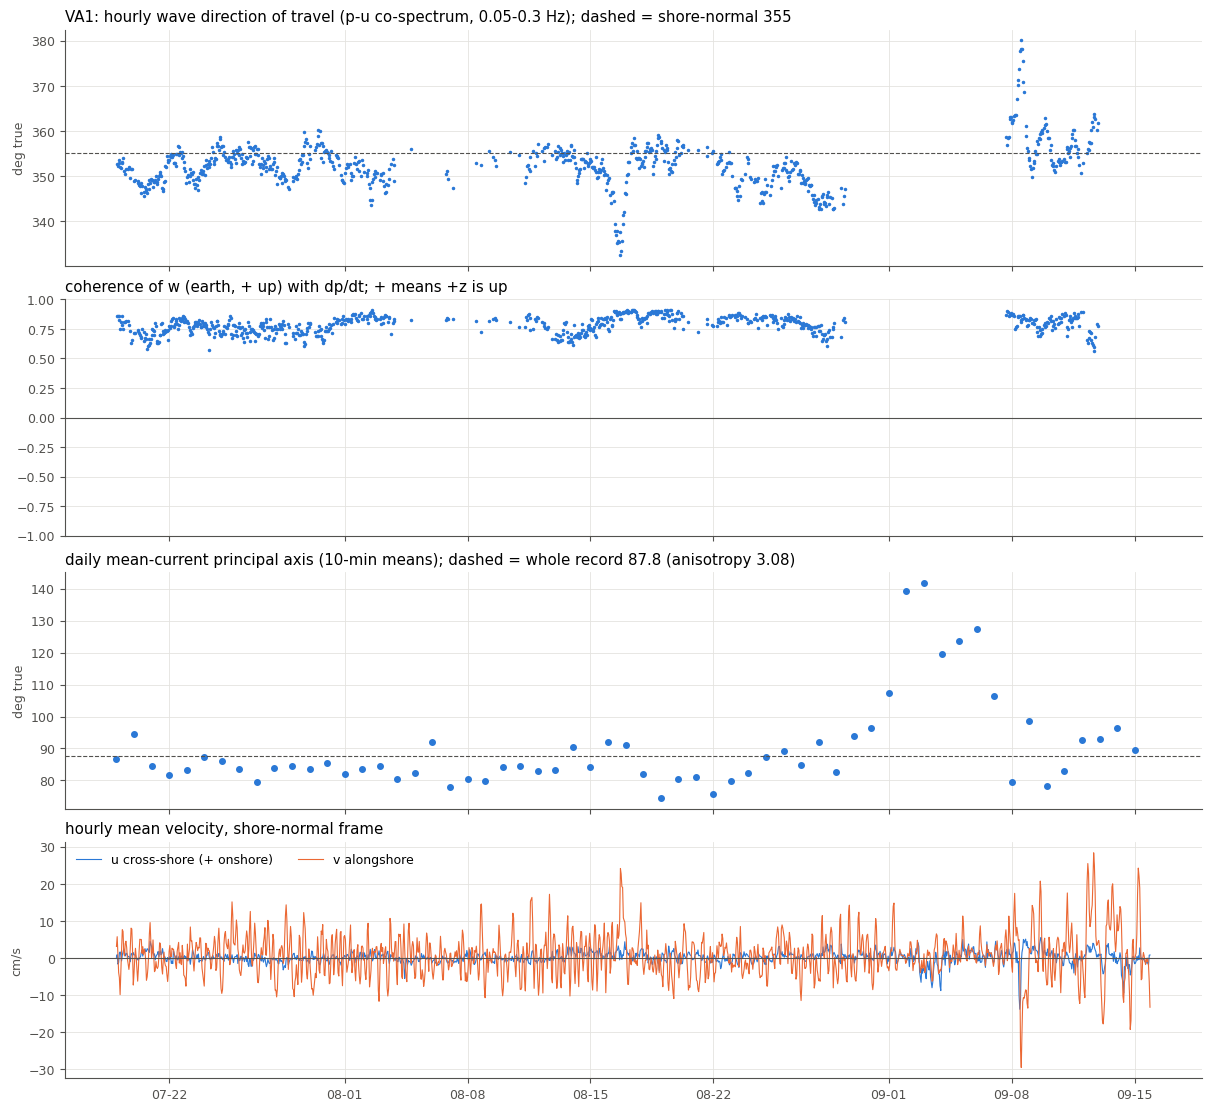

In [20]:
##-----rotation checks: vertical sign, wave direction, current axis-----##
# hourly, over gap-free 1-h segments, wave band 0.05-0.3 Hz
f  = np.fft.rfftfreq(seg_n, 1 / fs)
wb = (f >= 0.05) & (f <= 0.3)
V  = {"E": E, "N": N, "U": Up, "p": rot["p"].values.astype(float)}
rows = []
for h, g in pd.Series(np.arange(n), index=tq).groupby(tq.floor("1h")):
    ii = g.values
    if ii.size != seg_n or any(np.isnan(V[k][ii]).any() for k in V):
        continue
    F = {k: np.fft.rfft(V[k][ii] - V[k][ii].mean())[wb] for k in V}
    co = lambda a, b: np.real(np.sum(F[a] * np.conj(F[b])))
    # 1. w vs dp/dt: in phase (coherence ~ +1) when +z is really up
    Pdot = F["p"] * 1j * 2 * np.pi * f[wb]
    cw = np.real(np.sum(F["U"] * np.conj(Pdot))) / np.sqrt(np.sum(abs(F["U"]) ** 2) * np.sum(abs(Pdot) ** 2))
    # 2. wave direction of travel (bearing, true): horizontal velocity in phase with p points the way waves go
    wdir = np.degrees(np.arctan2(co("E", "p"), co("N", "p"))) % 360
    # 3. wave principal axis (dolfyn, 0-180 deg true) and its anisotropy
    x = np.vstack([V["E"][ii] - V["E"][ii].mean(), V["N"][ii] - V["N"][ii].mean()])
    ev_ = np.linalg.eigvalsh(np.cov(x))
    rows.append((h, cw, wdir, float(calc_principal_heading(x, tidal_mode=True)), np.sqrt(ev_[1] / ev_[0]),
                 np.sqrt(co("p", "p"))))
wv = pd.DataFrame(rows, columns=["hour", "coh_w_dpdt", "wave_dir", "wave_axis", "wave_aniso", "p_amp"]).set_index("hour")

def circ_median_dir(a, w=None):
    # weighted circular mean, deg
    w = np.ones_like(a) if w is None else w
    r = np.radians(a)
    return np.degrees(np.arctan2(np.sum(w * np.sin(r)), np.sum(w * np.cos(r)))) % 360

# daily mean-current principal axis: dolfyn calc_principal_heading on 10-min means (axis, 0-180)
m10 = pd.DataFrame({"E": E, "N": N}, index=tq).resample("10min").mean()
cur = []
for day, g in m10.groupby(m10.index.floor("1D")):
    g = g.dropna()
    if len(g) < 72:                                  # at least half a day of 10-min means
        continue
    x = np.vstack([g.E.values, g.N.values])
    e = np.linalg.eigvalsh(np.cov(x))
    cur.append((day, float(calc_principal_heading(x, tidal_mode=True)), np.sqrt(e[1] / e[0])))
cur = pd.DataFrame(cur, columns=["day", "cur_axis", "cur_aniso"]).set_index("day")
x_all = np.vstack([m10.E.dropna().values, m10.N.dropna().values])
e_all = np.linalg.eigvalsh(np.cov(x_all))
cur_axis_all, cur_aniso_all = float(calc_principal_heading(x_all, tidal_mode=True)), np.sqrt(e_all[1] / e_all[0])

wave_dir_mean = circ_median_dir(wv.wave_dir.values, wv.p_amp.values ** 2)   # energy-weighted
# the normal to the current axis, on the side the waves travel toward (onshore)
cur_normal = min([(cur_axis_all + 90) % 360, (cur_axis_all - 90) % 360],
                 key=lambda a: abs((a - wave_dir_mean + 180) % 360 - 180))
mean_E, mean_N = np.nanmean(E), np.nanmean(N)

print(f"{sensor_id}: {len(wv)} gap-free hours")
print(f"  1. w vs dp/dt coherence: median {wv.coh_w_dpdt.median():+.2f}, "
      f"{100 * (wv.coh_w_dpdt > 0).mean():.0f} % of hours > 0  (expect ~ +1 if +z is up)")
print(f"  2. wave direction of travel: energy-weighted mean {wave_dir_mean:.1f} deg true, hourly 5-95 % "
      f"{np.percentile(wv.wave_dir, 5):.0f}-{np.percentile(wv.wave_dir, 95):.0f}  (expect onshore, ~{SHORE_NORMAL_DEG:g})")
print(f"     wave principal axis: median {wv.wave_axis.median():.1f} deg (anisotropy {wv.wave_aniso.median():.2f})")
print(f"  3. mean-current principal axis (10-min means, whole record): {cur_axis_all:.1f} deg, anisotropy "
      f"{cur_aniso_all:.2f}; daily axis median {cur.cur_axis.median():.1f} (anisotropy {cur.cur_aniso.median():.2f})")
print(f"     normal to that axis, onshore side: {cur_normal:.1f} deg true")
print(f"  mean current: E {100 * mean_E:+.2f}, N {100 * mean_N:+.2f} cm/s -> toward "
      f"{np.degrees(np.arctan2(mean_E, mean_N)) % 360:.0f} deg true; cross-shore {100 * np.nanmean(u_sn):+.2f}, "
      f"alongshore {100 * np.nanmean(v_sn):+.2f} cm/s")
print(f"  shore-normal candidates (onshore, deg true): SHORE_NORMAL_DEG {SHORE_NORMAL_DEG:g} | waves {wave_dir_mean:.1f} "
      f"| current-axis normal {cur_normal:.1f}")

##-----figure-----##
fig, axs = plt.subplots(4, 1, figsize=(12, 11), sharex=True, constrained_layout=True)
ax = axs[0]
# unwrapped to within +-180 of the shore-normal, so a 359 -> 1 deg crossing does not jump
ax.plot(wv.index, (wv.wave_dir - SHORE_NORMAL_DEG + 180) % 360 - 180 + SHORE_NORMAL_DEG, ".", ms=3, color=SERIES)
ax.axhline(SHORE_NORMAL_DEG, color=INK2, ls="--", lw=0.8)
ax.set_ylabel("deg true")
ax.set_title(f"{sensor_id}: hourly wave direction of travel (p-u co-spectrum, 0.05-0.3 Hz); "
             f"dashed = shore-normal {SHORE_NORMAL_DEG:g}", loc="left")
ax = axs[1]
ax.plot(wv.index, wv.coh_w_dpdt, ".", ms=3, color=SERIES)
ax.axhline(0, color=INK2, lw=0.8)
ax.set_ylim(-1, 1)
ax.set_title("coherence of w (earth, + up) with dp/dt; + means +z is up", loc="left")
ax = axs[2]
# an axis: 5 and 175 deg are 10 deg apart, so plot within +-90 of the whole-record axis
ax.plot(cur.index, (cur.cur_axis - cur_axis_all + 90) % 180 - 90 + cur_axis_all, "o", ms=4, color=SERIES)
ax.axhline(cur_axis_all, color=INK2, ls="--", lw=0.8)
ax.set_ylabel("deg true")
ax.set_title(f"daily mean-current principal axis (10-min means); dashed = whole record {cur_axis_all:.1f} "
             f"(anisotropy {cur_aniso_all:.2f})", loc="left")
ax = axs[3]
m1 = pd.DataFrame({"u": u_sn, "v": v_sn}, index=tq).resample("1h").mean()
ax.plot(m1.index, 100 * m1.u, color=SERIES, lw=0.8, label="u cross-shore (+ onshore)")
ax.plot(m1.index, 100 * m1.v, color="#eb6834", lw=0.8, label="v alongshore")
ax.axhline(0, color=INK2, lw=0.8)
ax.set_ylabel("cm/s")
ax.legend(loc="upper left", frameon=False, ncol=2)
ax.set_title("hourly mean velocity, shore-normal frame", loc="left")
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
fig.savefig(fig_dir / f"{sensor_id}_rotate.png", dpi=150)
plt.show()

In [21]:
##-----save-----##
# same compression as the earlier sections. u, v, w are now shore-normal (u onshore, v alongshore,
# w up); u_east/v_north are true ENU; u_inst/v_inst/w_inst are the head-frame values from section 4.
wv_h = wv.reindex(pd.DatetimeIndex(rot["hour"].values))
for name in ["coh_w_dpdt", "wave_dir", "wave_axis", "wave_aniso"]:
    rot[f"{name}_h"] = ("hour", wv_h[name].values.astype("float32"))
rot["wave_dir_h"].attrs["comment"] = "wave direction of travel, deg true, from the p-u/p-v co-spectra (0.05-0.3 Hz)"
rot.attrs.update({
    "rot_heading_kvh_magnetic_deg": heading_mag,
    "rot_declination_deg": DECLINATION_DEG,
    "rot_declination_source": "WMM-2025 via NOAA NCEI calculator, 2026-08-15, 21.297 N 158.042 W (IGRF-14: 9.27)",
    "rot_heading_true_deg": heading_true,
    "rot_head_up": str(HEAD_UP),
    "rot_head_tilt": "assumed vertical (no head attitude sensor); canister heading/pitch/roll not used",
    "rot_shore_normal_deg": SHORE_NORMAL_DEG,
    "rot_shore_normal_source": ("sensor_notes.csv, transect shoreline heading - 90" if SHORE_NORMAL_OVERRIDE is None
                                else "SHORE_NORMAL_OVERRIDE"),
    "rot_wave_dir_mean_deg": wave_dir_mean,
    "rot_current_axis_deg": cur_axis_all,
    "rot_current_anisotropy": cur_aniso_all,
})
enc = {v: {"zlib": True, "complevel": 4} for v in rot.data_vars}
enc["time"] = {"zlib": True, "complevel": 4}
out_path = qc_dir / f"{sensor_id}_rotate.nc"
rot.to_netcdf(out_path, encoding=enc)
print(f"saved {out_path}  ({out_path.stat().st_size / 1e9:.2f} GB)")

saved /Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/data/processed/qc/VA1_rotate.nc  (0.31 GB)


### 6. Z-test, linear wave theory
Consistency of pressure and velocity (Elgar, Raubenheimer & Guza 2005, MST 16). Linear theory
predicts the pressure spectrum (in m of water) from the horizontal velocity spectrum:
- $$S_{pp,\,pred} = (S_{uu}+S_{vv})\,(\omega/gk)^2\,[\cosh(k z_p)/\cosh(k z_u)]^2$$
- $$Z = \Sigma\, S_{pp} S_\eta \,/\, \Sigma\, S_{pp,\,pred} S_\eta, \qquad S_\eta = S_{pp}\,[\cosh(kh)/\cosh(k z_p)]^2$$

summed over the sea-swell band. Z = 1 for a clean linear wave field; the lab catalog sits at a
median of ~0.97 (0.85–1.04 across records), a few per cent low because velocity noise inflates
$S_{uu}+S_{vv}$. A record median outside 0.5–2 flags a bad pressure or velocity channel (or a wrong
unit/height). It is a flag, not a gate: no segment is dropped. The cosh ratio corrects for p and u
at different heights (canister vs head); with $z_u = z_p$ it is 1, the lab's formula.

#### 6a. Per-segment Z

Input is `rot` from section 5 (only $S_{uu}+S_{vv}$ is used, which does not depend on the horizontal frame).
1. The record is cut into consecutive `ZT_SEG_S` (1024 s) segments. A segment is used if it is
   contiguous in time and has ≤ `NAN_MAX_FRAC` NaN in p, u, v; the NaNs are filled linearly (lab
   `fillmissing`).
2. Each segment is **linearly detrended**, then Welch spectra: `ZT_NFFT` (128 s) Hann windows, 50 %
   overlap (the lab's nfft = 256 at 2 Hz).
3. k from the full dispersion relation at h = mean p + `Z_P_HAB`; Z in the sea-swell band, weighted
   by $S_\eta$. Z_IG is also computed, but the IG band holds only ~5 bins at this resolution and bound
   IG waves do not follow free-wave dispersion, so it is a diagnostic only.
4. A synthetic linear wave is run through the same code first (the lab's `test_ztest_linear`): Z must
   come out as 1 (within 2 %), also with p and u at different heights, or the cell stops.

In [22]:
##-----Z-test: measured vs velocity-predicted pressure spectrum (linear theory)-----##
from scipy.signal import welch, detrend

def wavenumber(omega, h, g=GRAV):
    """k from omega^2 = g k tanh(k h) (Newton, vectorized). omega > 0."""
    omega = np.asarray(omega, float)
    k = np.maximum(omega ** 2 / g, omega / np.sqrt(g * h))       # deep / shallow-water start
    for _ in range(40):
        th = np.tanh(k * h)
        k = k - (g * k * th - omega ** 2) / (g * th + g * k * h * (1 - th ** 2))
    return k

def seg_spectra(p_m, u, v):
    """Welch spectra of one segment, after a linear detrend of the whole segment."""
    kw = dict(fs=fs, window="hann", nperseg=ZT_NFFT, noverlap=int(ZT_NFFT * ZT_OVERLAP), detrend=False)
    f, Spp = welch(detrend(p_m, type="linear"), **kw)
    _, Suu = welch(detrend(u, type="linear"), **kw)
    _, Svv = welch(detrend(v, type="linear"), **kw)
    return f, Spp, Suu + Svv

def z_from_spectra(f, Spp, Suv, h, z_p, z_u, band):
    """Z = sum(Spp * S_eta) / sum(Spp_pred * S_eta) over band (Elgar, Raubenheimer & Guza 2005).
    Spp_pred = (Suu + Svv) (omega / g k)^2 [cosh(k z_p) / cosh(k z_u)]^2   (p in m of water)
    S_eta    = Spp / Kp^2,  Kp = cosh(k z_p) / cosh(k h).  Arrays may carry a leading segment axis."""
    b = (f >= band[0]) & (f <= band[1])
    om = 2 * np.pi * f[b]
    h = np.atleast_1d(h)[:, None]
    k = wavenumber(om[None, :], h)
    pred = np.atleast_2d(Suv)[:, b] * (om / (GRAV * k)) ** 2 * (np.cosh(k * z_p) / np.cosh(k * z_u)) ** 2
    Spp_b = np.atleast_2d(Spp)[:, b]
    S_eta = Spp_b * (np.cosh(k * h) / np.cosh(k * z_p)) ** 2
    return np.sum(Spp_b * S_eta, 1) / np.sum(pred * S_eta, 1), S_eta, pred

# closure check on a synthetic linear wave (the lab's test_ztest_linear): Z must come out 1, also
# with p and u at different heights, or the formula is wrong
_t = np.arange(int(ZT_SEG_S * fs)) / fs
for _h, _zp, _zu in [(5.0, 0.2, 0.2), (10.0, 0.2, 0.8)]:
    _p = np.zeros_like(_t); _u = np.zeros_like(_t)
    for _f, _a in [(0.07, 0.3), (0.10, 0.5), (0.15, 0.3)]:
        _om = 2 * np.pi * _f; _k = float(wavenumber(_om, _h)); _ph = np.random.default_rng(1).uniform(0, 2 * np.pi)
        _p += _a * np.cosh(_k * _zp) / np.cosh(_k * _h) * np.cos(_om * _t + _ph)
        _u += _a * _om * np.cosh(_k * _zu) / np.sinh(_k * _h) * np.cos(_om * _t + _ph)
    _f_, _S, _Suv = seg_spectra(_p, _u, 0 * _u)
    _z = z_from_spectra(_f_, _S, _Suv, _h, _zp, _zu, ZT_F_SS)[0][0]
    assert abs(_z - 1) < 0.02, f"Z closure failed: {_z:.3f} at h {_h}, z_p {_zp}, z_u {_zu}"

# per-segment spectra. Input: `rot` from section 5 (Suu + Svv does not depend on the horizontal frame).
z_p = Z_P_HAB
z_u = Z_P_HAB if Z_U_HAB is None else Z_U_HAB
seg_len = int(ZT_SEG_S * fs)
P_all = rot["p"].values.astype(float) * 1e4 / (RHO * GRAV)       # dbar -> m of water
U_all, V_all = rot["u"].values.astype(float), rot["v"].values.astype(float)
n_seg = n // seg_len
seg_t, seg_h, seg_nan, spp, suv = [], [], [], [], []
for s in range(n_seg):
    sl = slice(s * seg_len, (s + 1) * seg_len)
    span = (tq[sl.stop - 1] - tq[sl.start]).total_seconds()
    X = [P_all[sl], U_all[sl], V_all[sl]]
    nan_frac = max(np.isnan(a).mean() for a in X)
    seg_t.append(tq[sl.start]); seg_nan.append(nan_frac)
    # a segment must be contiguous in time and mostly valid (lab nanMaxFrac); NaNs filled linearly
    if nan_frac > NAN_MAX_FRAC or abs(span - (seg_len - 1) / fs) > 1.0:
        seg_h.append(np.nan); spp.append(None); suv.append(None)
        continue
    X = [pd.Series(a).interpolate(limit_direction="both").values for a in X]
    f_z, S1, S2 = seg_spectra(*X)
    seg_h.append(np.mean(X[0]) + z_p)                            # total depth, bed to surface
    spp.append(S1); suv.append(S2)
ok = np.array([s is not None for s in spp])
Spp = np.vstack([s for s in spp if s is not None]); Suv = np.vstack([s for s in suv if s is not None])
h_ok = np.array(seg_h)[ok]

zt = pd.DataFrame({"h": seg_h, "nan_frac": seg_nan, "ok": ok}, index=pd.DatetimeIndex(seg_t, name="seg"))
Z_ss, S_eta_ss, pred_ss = z_from_spectra(f_z, Spp, Suv, h_ok, z_p, z_u, ZT_F_SS)
Z_ig = z_from_spectra(f_z, Spp, Suv, h_ok, z_p, z_u, ZT_F_IG)[0]
df_z = f_z[1] - f_z[0]
zt.loc[ok, "Z_SS"] = Z_ss
zt.loc[ok, "Z_IG"] = Z_ig
zt.loc[ok, "Hs_SS"] = 4 * np.sqrt(S_eta_ss.sum(1) * df_z)

# record-level verdict (lab ztest_record_flag): a FLAG, not a gate; no segment is dropped
zmed = float(np.nanmedian(Z_ss))
if ok.sum() < ZT_MIN_SEG:
    z_status = "insufficient"
elif ZT_WINDOW[0] <= zmed <= ZT_WINDOW[1]:
    z_status = "ok"
else:
    z_status = "FLAG"

print(f"{sensor_id}: {ok.sum()} of {n_seg} {ZT_SEG_S:g}-s segments valid; Welch {ZT_NFFT / fs:g} s Hann, "
      f"{100 * ZT_OVERLAP:g} % overlap, df {df_z:.4f} Hz; z_p {z_p:.2f} m, z_u {z_u:.2f} m above bed")
print(f"  Z_SS ({ZT_F_SS[0]}-{ZT_F_SS[1]} Hz): median {zmed:.3f}, 5-95 % {np.nanpercentile(Z_ss, 5):.3f}-"
      f"{np.nanpercentile(Z_ss, 95):.3f}, outside {ZT_WINDOW} in {100 * np.mean((Z_ss < ZT_WINDOW[0]) | (Z_ss > ZT_WINDOW[1])):.1f} % "
      f"of segments -> {z_status}")
print(f"  Z_IG ({ZT_F_IG[0]}-{ZT_F_IG[1]} Hz, {int(((f_z >= ZT_F_IG[0]) & (f_z <= ZT_F_IG[1])).sum())} bins): "
      f"median {np.nanmedian(Z_ig):.3f}   (few bins at this resolution; bound IG waves are not linear free waves)")
hs_t = np.nanpercentile(zt.Hs_SS, [33, 67])
for lab, m in [("small", zt.Hs_SS < hs_t[0]), ("mid", (zt.Hs_SS >= hs_t[0]) & (zt.Hs_SS < hs_t[1])), ("large", zt.Hs_SS >= hs_t[1])]:
    print(f"  Hs_SS {lab:5s} ({zt.Hs_SS[m].min():.2f}-{zt.Hs_SS[m].max():.2f} m): median Z_SS {zt.Z_SS[m].median():.3f}")
# the heights are estimates; how much would a different velocity height change Z?
sens = {dz: float(np.nanmedian(z_from_spectra(f_z, Spp, Suv, h_ok, z_p, max(z_u + dz, 0), ZT_F_SS)[0]))
        for dz in (-0.2, 0.2, 0.5)}
print("  height sensitivity, median Z_SS if z_u were: " +
      ", ".join(f"{z_u + dz:.2f} m -> {v:.3f}" for dz, v in sens.items()))

VA1: 4017 of 4967 1024-s segments valid; Welch 128 s Hann, 50 % overlap, df 0.0078 Hz; z_p 0.20 m, z_u 0.20 m above bed
  Z_SS (0.04-0.25 Hz): median 0.977, 5-95 % 0.900-1.086, outside (0.5, 2.0) in 0.0 % of segments -> ok
  Z_IG (0.004-0.04 Hz, 5 bins): median 0.690   (few bins at this resolution; bound IG waves are not linear free waves)
  Hs_SS small (0.65-1.06 m): median Z_SS 0.954
  Hs_SS mid   (1.06-1.45 m): median Z_SS 0.967
  Hs_SS large (1.45-5.69 m): median Z_SS 1.017
  height sensitivity, median Z_SS if z_u were: 0.00 m -> 0.976, 0.40 m -> 0.977, 0.70 m -> 0.978


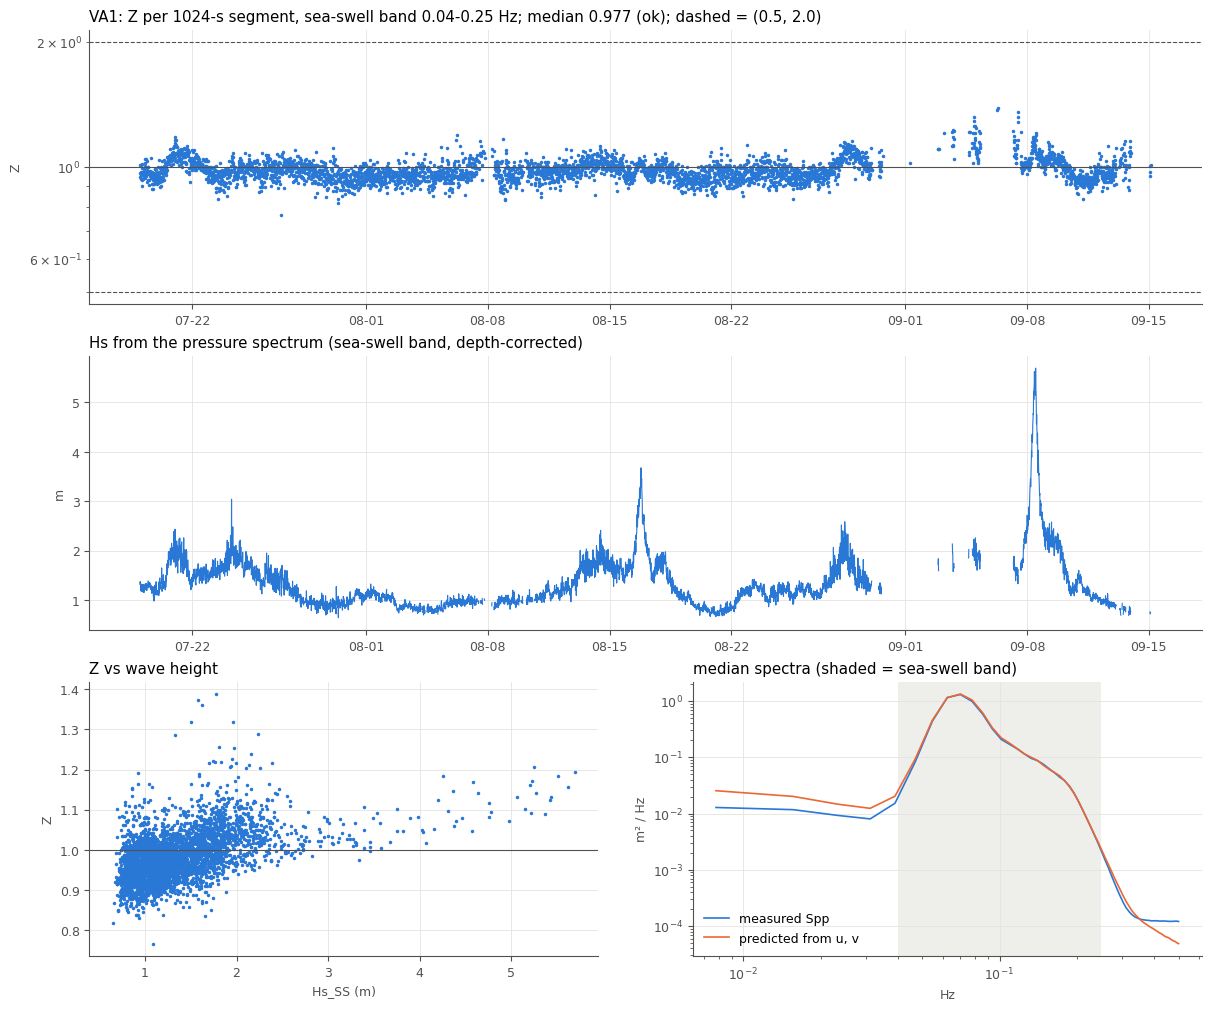

In [23]:
##-----figure: Z-test-----##
fig = plt.figure(figsize=(12, 10), constrained_layout=True)
gs = fig.add_gridspec(3, 2)
ax = fig.add_subplot(gs[0, :])
ax.plot(zt.index, zt.Z_SS, ".", ms=3, color=SERIES)
ax.axhline(1, color=INK2, lw=0.8)
for y in ZT_WINDOW:
    ax.axhline(y, color=INK2, ls="--", lw=0.8)
ax.set_yscale("log")
ax.set_ylabel("Z")
ax.set_title(f"{sensor_id}: Z per {ZT_SEG_S:g}-s segment, sea-swell band {ZT_F_SS[0]}-{ZT_F_SS[1]} Hz; "
             f"median {zmed:.3f} ({z_status}); dashed = {ZT_WINDOW}", loc="left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax2 = fig.add_subplot(gs[1, :], sharex=ax)
ax2.plot(zt.index, zt.Hs_SS, color=SERIES, lw=0.8)
ax2.set_ylabel("m")
ax2.set_title("Hs from the pressure spectrum (sea-swell band, depth-corrected)", loc="left")
ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(zt.Hs_SS, zt.Z_SS, ".", ms=3, color=SERIES)
ax3.axhline(1, color=INK2, lw=0.8)
ax3.set_xlabel("Hs_SS (m)")
ax3.set_ylabel("Z")
ax3.set_title("Z vs wave height", loc="left")
ax4 = fig.add_subplot(gs[2, 1])
b = (f_z > 0) & (f_z <= 0.5)
om = 2 * np.pi * f_z[b]
k_med = wavenumber(om, np.median(h_ok))
pred_med = np.median(Suv[:, b], 0) * (om / (GRAV * k_med)) ** 2 * (np.cosh(k_med * z_p) / np.cosh(k_med * z_u)) ** 2
ax4.loglog(f_z[b], np.median(Spp[:, b], 0), color=SERIES, lw=1.2, label="measured Spp")
ax4.loglog(f_z[b], pred_med, color="#eb6834", lw=1.2, label="predicted from u, v")
ax4.axvspan(*ZT_F_SS, color=GRID, alpha=0.6, lw=0)
ax4.set_xlabel("Hz")
ax4.set_ylabel("m² / Hz")
ax4.legend(frameon=False, loc="lower left")
ax4.set_title("median spectra (shaded = sea-swell band)", loc="left")
fig.savefig(fig_dir / f"{sensor_id}_ztest.png", dpi=150)
plt.show()

In [24]:
##-----save-----##
# small file: one row per segment (dim "seg") plus the median spectra (dim "freq")
zds = xr.Dataset(
    {"Z_SS": ("seg", zt.Z_SS.values.astype("float32")),
     "Z_IG": ("seg", zt.Z_IG.values.astype("float32")),
     "Hs_SS": ("seg", zt.Hs_SS.values.astype("float32"), {"units": "m"}),
     "depth": ("seg", zt.h.values.astype("float32"), {"units": "m", "long_name": "mean p (m) + z_p"}),
     "nan_frac": ("seg", zt.nan_frac.values.astype("float32")),
     "seg_ok": ("seg", zt.ok.values),
     "Spp_median": ("freq", np.median(Spp, 0).astype("float32"), {"units": "m2 Hz-1"}),
     "SuuSvv_median": ("freq", np.median(Suv, 0).astype("float32"), {"units": "m2 s-2 Hz-1"})},
    coords={"seg": zt.index.values, "freq": f_z},
    attrs={"sensor_id": sensor_id, "zt_segment_s": ZT_SEG_S, "zt_welch_nfft": ZT_NFFT, "zt_welch_overlap": ZT_OVERLAP,
           "zt_detrend": "linear, per segment", "zt_band_ss_hz": list(ZT_F_SS), "zt_band_ig_hz": list(ZT_F_IG),
           "zt_z_p_m": z_p, "zt_z_u_m": z_u, "zt_window": list(ZT_WINDOW), "zt_median_Z_SS": zmed,
           "zt_status": z_status, "zt_n_seg": int(ok.sum()),
           "zt_formula": "Z = sum(Spp S_eta)/sum(Spp_pred S_eta); Spp_pred = (Suu+Svv)(w/gk)^2 [cosh(k z_p)/cosh(k z_u)]^2"})
out_path = qc_dir / f"{sensor_id}_ztest.nc"
zds.to_netcdf(out_path)
print(f"saved {out_path}")

saved /Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/data/processed/qc/VA1_ztest.nc


### Run the other sensors
Off by default. Once the pipeline is verified on VC1:
1. fill `SENSORS` in the parameters cell (section 0),
2. save the notebook (the batch cell reads it from disk),
3. set `RUN_BATCH = True` in the cell below and run that cell on its own.

Each sensor runs in a fresh kernel, with `sensor_id` overridden. The executed copy, with all
printed QC numbers and figures, goes to `processing/qc_runs/adv_QC_{sensor}.ipynb`, so each sensor
can be reviewed the same way VC1 was. Thresholds tuned on VC1/VC2 (e.g. `HEAD_STD_MAX`) should be
checked in each copy.